In [ ]:
# -*- coding: utf-8 -*-
"""
Treinamento CNN para detecção de picos R em sinais de ECG
Autor: Thiago Oliveira
Reescrito para melhor organização e legibilidade
"""

# ======================================================
# 📦 Importações
# ======================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras import layers, Input, Model, models
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# ======================================================
# 📂 Montar Google Drive e definir caminhos
# ======================================================
from google.colab import drive
drive.mount('/content/drive')

# Ajuste conforme a organização real do seu dataset
ECG_PATH = '/content/drive/My Drive/Dataset_PicoR/data'
RPEAK_PATH = '/content/drive/My Drive/Dataset_PicoR/ref'
SAVE_MODEL_PATH = '/content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras'

# ======================================================
# ⚙️ Funções de pré-processamento
# ======================================================

def remove_spikes(data, threshold=20):
    """Remove valores acima de um limiar (20 mV) substituindo pelo valor anterior."""
    indices = np.where(data > threshold)[0]
    for idx in indices:
        if idx > 0:
            data[idx] = data[idx - 1]
    return data

def normalize_mean(data):
    """Remove a média do sinal para normalização."""
    return data - np.mean(data)

def create_binary_labels(length, r_peaks, output_length):
    """
    Cria vetor binário indicando picos R.
    Redimensiona para output_length mantendo se houve pico no segmento.
    """
    labels = np.zeros(length)
    for peak in r_peaks:
        if peak < length:
            labels[peak] = 1
    factor = length // output_length
    return np.array([max(labels[i*factor:(i+1)*factor]) for i in range(output_length)])

def load_dataset(ecg_path, rpeak_path, output_length):
    """Carrega os sinais de ECG e picos R dos arquivos .mat"""
    x_data, y_data = [], []

    ecg_files = sorted([f for f in os.listdir(ecg_path) if f.endswith(".mat")])
    rpeak_files = sorted([f for f in os.listdir(rpeak_path) if f.endswith(".mat")])

    for ecg_file, rpeak_file in zip(ecg_files, rpeak_files):
        ecg = io.loadmat(os.path.join(ecg_path, ecg_file))['ecg'].flatten()
        rpeaks = io.loadmat(os.path.join(rpeak_path, rpeak_file))['R_peak'].flatten()

        ecg = remove_spikes(ecg)
        ecg = normalize_mean(ecg)
        labels = create_binary_labels(len(ecg), rpeaks, output_length)

        x_data.append(np.expand_dims(ecg, axis=-1))
        y_data.append(labels)

    return np.array(x_data), np.array(y_data)

# ======================================================
# 🧠 Criação do modelo CNN
# ======================================================

def create_model(input_shape, output_length):
    inputs = Input(shape=input_shape)

    # ========================
    # 📦 Bloco 1 - Convolução padrão
    # ========================
    x1 = layers.Conv1D(16, 11, padding='same', activation='relu')(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling1D(2)(x1)
    x1 = layers.Conv1D(32, 7, padding='same', activation='relu')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling1D(2)(x1)
    x1 = layers.Dropout(0.2)(x1)
    x1 = layers.GlobalAveragePooling1D()(x1)  # saída ~ (32,)

    # ========================
    # 📦 Bloco 2 - Dilation rate 2
    # ========================
    x2 = layers.Conv1D(16, 11, dilation_rate=2, padding='same', activation='relu')(inputs)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling1D(2)(x2)
    x2 = layers.Conv1D(32, 7, dilation_rate=2, padding='same', activation='relu')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling1D(2)(x2)
    x2 = layers.Dropout(0.25)(x2)
    x2 = layers.GlobalAveragePooling1D()(x2)  # saída ~ (32,)

    # ========================
    # 📦 Bloco 3 - Dilation rate 4
    # ========================
    x3 = layers.Conv1D(16, 11, dilation_rate=4, padding='same', activation='relu')(inputs)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling1D(2)(x3)
    x3 = layers.Conv1D(32, 7, dilation_rate=4, padding='same', activation='relu')(x3)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling1D(2)(x3)
    x3 = layers.GlobalAveragePooling1D()(x3)  # saída ~ (32,)

    # ========================
    # 🔗 Combinação dos blocos
    # ========================
    merged = layers.concatenate([x1, x2, x3])  # ~ (96,)

    # ========================
    # 🎯 Gating (máscara adaptativa)
    # ========================
    mask = layers.Dense(96, activation='sigmoid')(merged)  # mesma dimensão que merged
    gated = layers.Multiply()([mask, merged])

    # ========================
    # 🔽 Camadas densas finais
    # ========================
    x = layers.Dense(96, activation='relu')(gated)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    # ========================
    # 📤 Saída
    # ========================
    outputs = layers.Dense(output_length, activation='sigmoid')(x)

    # ========================
    # 🏗️ Modelo
    # ========================
    return Model(inputs, outputs)


# ======================================================
# 🚀 Execução do treinamento
# ======================================================

input_shape = (5000, 1)
output_length = 625

# Carregar dados
X, Y = load_dataset(ECG_PATH, RPEAK_PATH, output_length)

# Garantir mesmo número de amostras
n_samples = min(len(X), len(Y))
X, Y = X[:n_samples], Y[:n_samples]

# Dividir treino/validação
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Criar modelo
model = create_model(input_shape, output_length)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['binary_accuracy'])

# Treinar
model.fit(X_train, y_train, epochs=60, batch_size=200, validation_split=0.2)

# Salvar modelo
model.save(SAVE_MODEL_PATH)
print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")


Mounted at /content/drive
Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - binary_accuracy: 0.5089 - loss: 0.6931 - val_binary_accuracy: 0.7799 - val_loss: 0.6928
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - binary_accuracy: 0.5300 - loss: 0.6921 - val_binary_accuracy: 0.7959 - val_loss: 0.6924
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - binary_accuracy: 0.5505 - loss: 0.6909 - val_binary_accuracy: 0.7912 - val_loss: 0.6919
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.5699 - loss: 0.6896 - val_binary_accuracy: 0.7865 - val_loss: 0.6914
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - binary_accuracy: 0.5857 - loss: 0.6882 - val_binary_accuracy: 0.7883 - val_loss: 0.6907
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - binary_accuracy: 0.6006 - loss: 0.6863 - val_binary_accuracy: 0.7932 - val_loss: 0.6900
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.6151 - loss: 0.6840 - val_binary_accuracy: 0.8002 - val_loss: 0.6892
Ep

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Máximo da previsão: 0.37063253


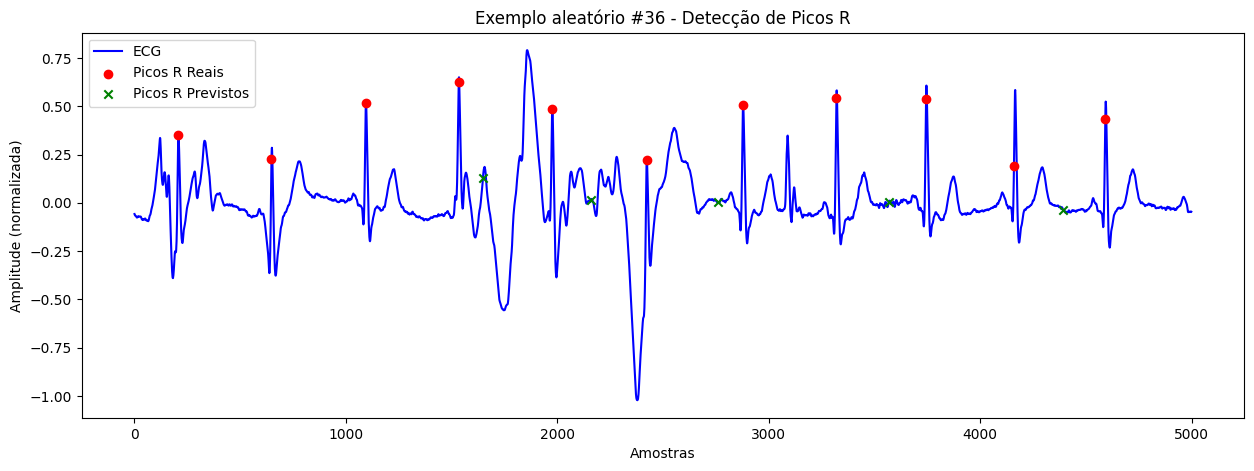

In [ ]:
# Fazer previsão
pred_probs = model.predict(X_val[idx:idx+1])[0]  # vetor (625,)
print("Máximo da previsão:", np.max(pred_probs))  # debug

# Ajustar limiar se necessário
threshold = 0.3
pred_classes = (pred_probs > threshold).astype(int)

# Localizar picos reais e previstos
real_peaks = np.where(y_val[idx] == 1)[0]
pred_peaks = np.where(pred_classes == 1)[0]

# Converter para índices no sinal original
scale_factor = X_val.shape[1] // pred_probs.shape[0]  # 5000/625 = 8
real_peaks_samples = real_peaks * scale_factor
pred_peaks_samples = pred_peaks * scale_factor

# Plotagem
plt.figure(figsize=(15, 5))
plt.plot(X_val[idx].squeeze(), color='blue', label='ECG')

plt.scatter(real_peaks_samples,
            X_val[idx].squeeze()[real_peaks_samples],
            color='red', label='Picos R Reais', zorder=3)

plt.scatter(pred_peaks_samples,
            X_val[idx].squeeze()[pred_peaks_samples],
            color='green', marker='x', label='Picos R Previstos', zorder=3)

plt.title(f"Exemplo aleatório #{idx} - Detecção de Picos R")
plt.xlabel("Amostras")
plt.ylabel("Amplitude (normalizada)")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


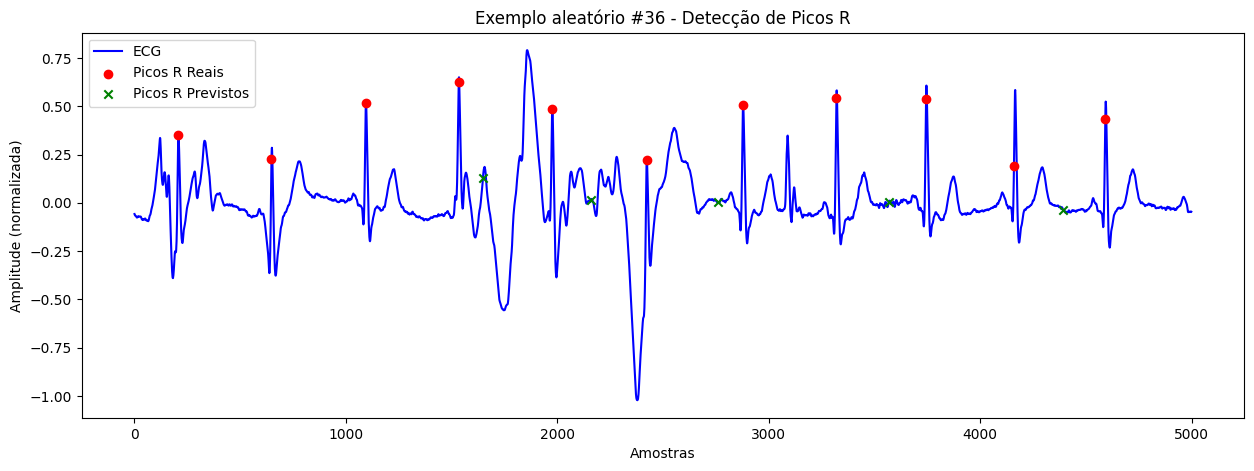

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Fazer previsão
pred_probs = model.predict(X_val[idx:idx+1])[0]  # (625,)

# Limiar
threshold = 0.3
pred_classes = (pred_probs > threshold).astype(int)

# Agrupar e pegar só o máximo de cada grupo
pred_peaks = []
i = 0
while i < len(pred_classes):
    if pred_classes[i] == 1:
        start = i
        while i < len(pred_classes) and pred_classes[i] == 1:
            i += 1
        end = i
        # Pegar índice com maior probabilidade no grupo
        max_idx = start + np.argmax(pred_probs[start:end])
        pred_peaks.append(max_idx)
    else:
        i += 1

pred_peaks = np.array(pred_peaks)

# Converter para amostras originais
scale_factor = X_val.shape[1] // pred_probs.shape[0]  # 5000/625 = 8
pred_peaks_samples = pred_peaks * scale_factor

# Reais
real_peaks = np.where(y_val[idx] == 1)[0]
real_peaks_samples = real_peaks * scale_factor

# Plot
plt.figure(figsize=(15, 5))
plt.plot(X_val[idx].squeeze(), color='blue', label='ECG')

plt.scatter(real_peaks_samples,
            X_val[idx].squeeze()[real_peaks_samples],
            color='red', label='Picos R Reais', zorder=3)

plt.scatter(pred_peaks_samples,
            X_val[idx].squeeze()[pred_peaks_samples],
            color='green', marker='x', label='Picos R Previstos', zorder=3)

plt.title(f"Exemplo aleatório #{idx} - Detecção de Picos R")
plt.xlabel("Amostras")
plt.ylabel("Amplitude (normalizada)")
plt.legend()
plt.show()


Mounted at /content/drive
✅ Médias salvas em: /content/drive/My Drive/Dataset_PicoR/ecg_means.npy
Epoch 1/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - binary_accuracy: 0.5116 - loss: 0.6934 - val_binary_accuracy: 0.8187 - val_loss: 0.6928
Epoch 2/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.5330 - loss: 0.6921 - val_binary_accuracy: 0.8631 - val_loss: 0.6924
Epoch 3/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - binary_accuracy: 0.5521 - loss: 0.6908 - val_binary_accuracy: 0.8611 - val_loss: 0.6919
Epoch 4/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.5717 - loss: 0.6895 - val_binary_accuracy: 0.8540 - val_loss: 0.6915
Epoch 5/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.5862 - loss: 0.6879 - val_binary_accuracy: 0.8503 - val_loss: 0.6909
Epoch 6/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - binary_accuracy: 0.6022 - loss: 0.6859 - val_binary_accuracy: 0.8490 - val_loss: 0.6903
Epoch 7/60
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - binary_accuracy: 0

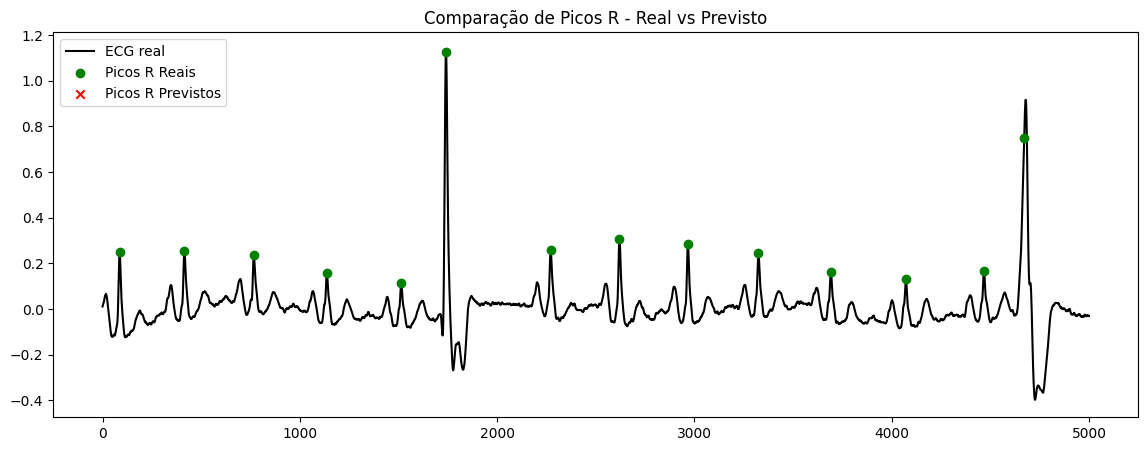

In [ ]:
# -*- coding: utf-8 -*-
"""
Treinamento CNN para detecção de picos R em sinais de ECG
Autor: Thiago Oliveira
Adaptado para salvar scaler (média) e corrigir desalinhamento na previsão
"""

# ======================================================
# 📦 Importações
# ======================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.optimizers import Adam
from google.colab import drive

# ======================================================
# 📂 Montar Google Drive e definir caminhos
# ======================================================
drive.mount('/content/drive')

ECG_PATH = '/content/drive/My Drive/Dataset_PicoR/data'
RPEAK_PATH = '/content/drive/My Drive/Dataset_PicoR/ref'
SAVE_MODEL_PATH = '/content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras'
SAVE_MEANS_PATH = '/content/drive/My Drive/Dataset_PicoR/ecg_means.npy'

# ======================================================
# ⚙️ Funções de pré-processamento
# ======================================================
def remove_spikes(data, threshold=20):
    """Remove valores acima de um limiar substituindo pelo valor anterior."""
    indices = np.where(data > threshold)[0]
    for idx in indices:
        if idx > 0:
            data[idx] = data[idx - 1]
    return data

def create_binary_labels(length, r_peaks, output_length):
    """Cria vetor binário indicando picos R e redimensiona."""
    labels = np.zeros(length)
    for peak in r_peaks:
        if peak < length:
            labels[peak] = 1
    factor = length // output_length
    return np.array([max(labels[i*factor:(i+1)*factor]) for i in range(output_length)])

def load_dataset(ecg_path, rpeak_path, output_length):
    """Carrega os sinais de ECG e picos R dos arquivos .mat"""
    x_data, y_data, means = [], [], []

    ecg_files = sorted([f for f in os.listdir(ecg_path) if f.endswith(".mat")])
    rpeak_files = sorted([f for f in os.listdir(rpeak_path) if f.endswith(".mat")])

    for ecg_file, rpeak_file in zip(ecg_files, rpeak_files):
        ecg = io.loadmat(os.path.join(ecg_path, ecg_file))['ecg'].flatten()
        rpeaks = io.loadmat(os.path.join(rpeak_path, rpeak_file))['R_peak'].flatten()

        ecg = remove_spikes(ecg)
        mean_val = np.mean(ecg)  # 📌 Guardar média original
        means.append(mean_val)

        ecg = ecg - mean_val  # Normalizar removendo média
        labels = create_binary_labels(len(ecg), rpeaks, output_length)

        x_data.append(np.expand_dims(ecg, axis=-1))
        y_data.append(labels)

    return np.array(x_data), np.array(y_data), np.array(means)

# ======================================================
# 🧠 Criação do modelo CNN
# ======================================================
def create_model(input_shape, output_length):
    inputs = Input(shape=input_shape)

    # Bloco 1
    x1 = layers.Conv1D(16, 11, padding='same', activation='relu')(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling1D(2)(x1)
    x1 = layers.Conv1D(32, 7, padding='same', activation='relu')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.MaxPooling1D(2)(x1)
    x1 = layers.Dropout(0.2)(x1)
    x1 = layers.GlobalAveragePooling1D()(x1)

    # Bloco 2
    x2 = layers.Conv1D(16, 11, dilation_rate=2, padding='same', activation='relu')(inputs)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling1D(2)(x2)
    x2 = layers.Conv1D(32, 7, dilation_rate=2, padding='same', activation='relu')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.MaxPooling1D(2)(x2)
    x2 = layers.Dropout(0.25)(x2)
    x2 = layers.GlobalAveragePooling1D()(x2)

    # Bloco 3
    x3 = layers.Conv1D(16, 11, dilation_rate=4, padding='same', activation='relu')(inputs)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling1D(2)(x3)
    x3 = layers.Conv1D(32, 7, dilation_rate=4, padding='same', activation='relu')(x3)
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.MaxPooling1D(2)(x3)
    x3 = layers.GlobalAveragePooling1D()(x3)

    # Combinação dos blocos
    merged = layers.concatenate([x1, x2, x3])

    # Gating
    mask = layers.Dense(96, activation='sigmoid')(merged)
    gated = layers.Multiply()([mask, merged])

    # Camadas densas finais
    x = layers.Dense(96, activation='relu')(gated)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(output_length, activation='sigmoid')(x)
    return Model(inputs, outputs)

# ======================================================
# 🚀 Treinamento
# ======================================================
input_shape = (5000, 1)
output_length = 625

# Carregar dados
X, Y, means = load_dataset(ECG_PATH, RPEAK_PATH, output_length)

# Salvar médias
np.save(SAVE_MEANS_PATH, means)
print(f"✅ Médias salvas em: {SAVE_MEANS_PATH}")

# Garantir mesmo número de amostras
n_samples = min(len(X), len(Y))
X, Y, means = X[:n_samples], Y[:n_samples], means[:n_samples]

# Dividir treino/validação
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

# Criar e compilar modelo
model = create_model(input_shape, output_length)
model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['binary_accuracy'])

# Treinar
model.fit(X_train, y_train, epochs=60, batch_size=200, validation_split=0.2)

# Salvar modelo
model.save(SAVE_MODEL_PATH)
print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")

# ======================================================
# 🔍 Teste e Plot
# ======================================================
from tensorflow.keras.models import load_model

# Carregar modelo e médias
model = load_model(SAVE_MODEL_PATH)
means = np.load(SAVE_MEANS_PATH)

# Escolher exemplo aleatório
idx = np.random.randint(0, len(X))
print(f"🔍 Testando exemplo #{idx}")

# Carregar sinal original e referência
ecg_raw = io.loadmat(os.path.join(ECG_PATH, sorted(os.listdir(ECG_PATH))[idx]))['ecg'].flatten()
rpeaks_ref = io.loadmat(os.path.join(RPEAK_PATH, sorted(os.listdir(RPEAK_PATH))[idx]))['R_peak'].flatten()

# Normalizar com a mesma média do treino
mean_val = means[idx]
ecg_norm = ecg_raw - mean_val

# Prever
pred = model.predict(np.expand_dims(ecg_norm, axis=(0, -1)))[0]

# Encontrar picos previstos
pred_threshold = 0.5
pred_peaks = np.where(pred > pred_threshold)[0] * (len(ecg_raw) // output_length)

# Plot
plt.figure(figsize=(14,5))
plt.plot(ecg_raw, label="ECG real", color="black")
plt.scatter(rpeaks_ref, ecg_raw[rpeaks_ref], color="green", label="Picos R Reais", zorder=5)
plt.scatter(pred_peaks, ecg_raw[pred_peaks], color="red", label="Picos R Previstos", marker="x", zorder=5)
plt.legend()
plt.title("Comparação de Picos R - Real vs Previsto")
plt.show()


Mounted at /content/drive
Carregando dados...
X: (2000, 5000, 1), Y_dt: (2000, 5000, 1), registros: 2000


Model: "UNet1D_DT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 5000, 16)  │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 5000, 16)  │        288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 5000, 16)  │        320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 5000, 16)  │        352 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 5000, 16)  │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 16)  │         64 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 16)  │         64 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 16)  │         64 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 5000, 16)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 5000, 16)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 5000, 16)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 5000, 16)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5000, 64)  │          0 │ leaky_re_lu[0][0… │
│ (Concatenate)       │                   │            │ leaky_re_lu_1[0]… │
│                     │                   │            │ leaky_re_lu_2[0]… │
│                     │                   │            │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 5000, 64)  │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 5000, 64)  │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 5000, 64)  │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ batch_normalizat

 Total params: 25,334,529 (96.64 MB)

 Trainable params: 25,324,801 (96.61 MB)

 Non-trainable params: 9,728 (38.00 KB)

Treinando...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.2339
Epoch 1: val_loss improved from inf to 11.79547, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 105s 681ms/step - loss: 0.2292 - val_loss: 11.7955 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0249
Epoch 2: val_loss improved from 11.79547 to 0.66265, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - loss: 0.0248 - val_loss: 0.6627 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0160
Epoch 3: val_loss improved from 0.66265 to 0.12371, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - loss: 0.0160 - val_loss: 0.1237 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0118
Epoch 4: val_loss improved fro

/tmp/ipython-input-1841439208.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


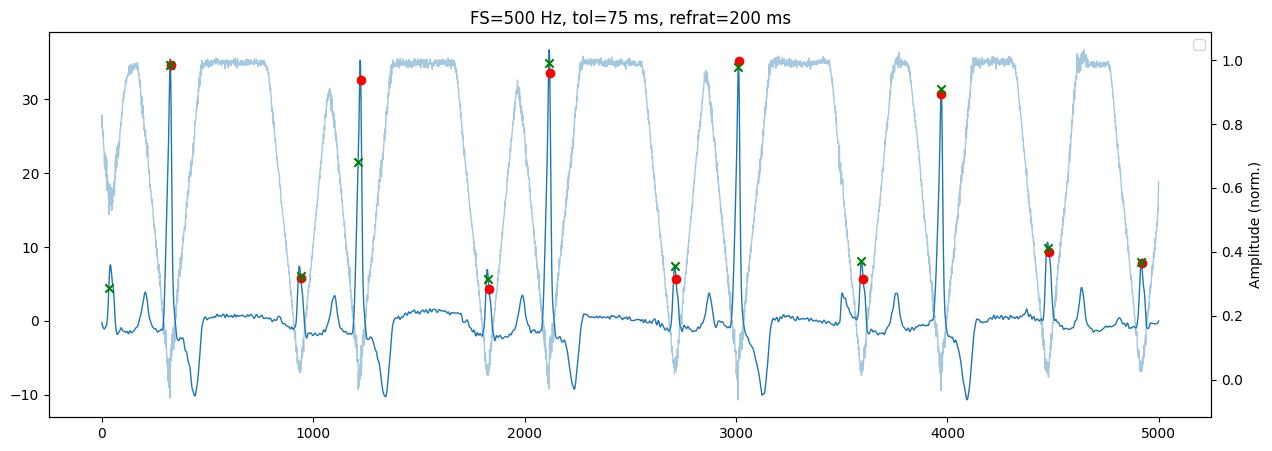

In [ ]:
# -*- coding: utf-8 -*-
"""
Detecção de picos R com U-Net 1D (estilo RPNet) + passa-banda 0.5–40 Hz
- Entrada: ecg (5000,1), R (k,1) ou R_peak (k,1) com índices 0..4999
- Rótulo: Distance Transform (DT) tamanho 5000 (regressão)
- Modelo: U-Net 1D + Inception-Residual (com crop para alinhar skips)
- Loss: Huber (Smooth L1)
- Pós-processamento: vales do DT + período refratário
- Métrica: Precision/Recall/F1 @ ±75 ms
"""

# =============================== #
# Imports
# =============================== #
import os
import numpy as np
from scipy import io
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import distance_transform_edt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt

# =============================== #
# Parâmetros
# =============================== #
FS = 500                   # Hz
WIN_SEC = 10               # s
WIN_SAMPLES = FS * WIN_SEC # 5000
REFRACT_MS = 200           # ms (refratário p/ detecção)
TOL_MS = 75                # ms (tolerância métrica)
REFRACT_SAMPLES = int(REFRACT_MS * FS / 1000)  # 100
TOL_SAMPLES = int(TOL_MS * FS / 1000)          # 37

EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-3

# Caminhos (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

ECG_PATH = '/content/drive/My Drive/Dataset_PicoR/data'
RPEAK_PATH = '/content/drive/My Drive/Dataset_PicoR/ref'
SAVE_MODEL_PATH = '/content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras'

# =============================== #
# Utils de Sinal
# =============================== #
def remove_spikes(data, threshold=20.0):
    x = np.asarray(data, dtype=np.float32).copy()
    idx = np.where(x > threshold)[0]
    for i in idx:
        if i > 0:
            x[i] = x[i-1]
    return x

def bandpass_filter(x, fs=FS, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='bandpass')
    return filtfilt(b, a, x).astype(np.float32)

def robust_normalize(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    return (x - med) / mad

def pad_or_trim_to_length(x, length):
    x = np.asarray(x).flatten()
    if len(x) == length:
        return x
    if len(x) > length:
        return x[:length]
    out = np.zeros(length, dtype=x.dtype)
    out[:len(x)] = x
    return out

# =============================== #
# Labels: Distance Transform (DT)
# =============================== #
def make_dt_label(length, rpeaks_idx, clip_samples=150):
    """
    DT normalizado (0..1) com recorte superior (ex.: 150 amostras ~ 300 ms).
    """
    mask = np.zeros(length, dtype=bool)
    r = np.asarray(rpeaks_idx, dtype=int)
    r = r[(r >= 0) & (r < length)]
    mask[r] = True
    dt = distance_transform_edt(~mask).astype(np.float32)
    dt = np.clip(dt, 0, clip_samples) / float(clip_samples)
    return dt

# =============================== #
# Modelo: U-Net 1D (Inception-Res)
# =============================== #
def conv_block(x, filters, k=3):
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(negative_slope=0.2)(x)

def inception_res_block(x, filters):
    b1 = conv_block(x, filters//4, k=15)
    b2 = conv_block(x, filters//4, k=17)
    b3 = conv_block(x, filters//4, k=19)
    b4 = conv_block(x, filters//4, k=21)
    y  = layers.Concatenate()([b1, b2, b3, b4])
    y  = layers.Conv1D(filters, 1, padding="same")(y)
    y  = layers.BatchNormalization()(y)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    y  = layers.Add()([x, y])
    return layers.LeakyReLU(negative_slope=0.2)(y)

def crop_decoder_to_encoder(dec, enc):
    """
    Corta o mapa do DECODER no eixo temporal para ter MESMO comprimento do ENCODER.
    (resolve 626 vs 625, etc.)
    """
    def _crop(args):
        d, e = args
        d_len = tf.shape(d)[1]
        e_len = tf.shape(e)[1]
        start = tf.maximum((d_len - e_len) // 2, 0)
        return d[:, start:start + e_len, :]
    return layers.Lambda(_crop)([dec, enc])

def build_unet1d(input_len=WIN_SAMPLES):
    inp = Input(shape=(input_len, 1))
    # Encoder
    e1 = inception_res_block(inp, 64)                           # 5000
    p1 = layers.Conv1D(64, 4, strides=2, padding="same")(e1)    # 2500

    e2 = inception_res_block(p1, 128)                           # 2500
    p2 = layers.Conv1D(128, 4, strides=2, padding="same")(e2)   # 1250

    e3 = inception_res_block(p2, 256)                           # 1250
    p3 = layers.Conv1D(256, 4, strides=2, padding="same")(e3)   # 625

    e4 = inception_res_block(p3, 512)                           # 625
    p4 = layers.Conv1D(512, 4, strides=2, padding="same")(e4)   # 313 (ceil)

    b  = inception_res_block(p4, 512)                           # 313

    # Decoder (sempre corta decoder para igualar encoder antes da concat)
    u4 = layers.Conv1DTranspose(512, 4, strides=2, padding="same")(b)  # 313->626
    u4 = crop_decoder_to_encoder(u4, e4)                                 # 626->625
    u4 = layers.Concatenate()([u4, e4])
    u4 = inception_res_block(u4, 512)                                    # 625

    u3 = layers.Conv1DTranspose(256, 4, strides=2, padding="same")(u4)  # 625->1250
    u3 = crop_decoder_to_encoder(u3, e3)                                 # já bate
    u3 = layers.Concatenate()([u3, e3])
    u3 = inception_res_block(u3, 256)                                    # 1250

    u2 = layers.Conv1DTranspose(128, 4, strides=2, padding="same")(u3)  # 1250->2500
    u2 = crop_decoder_to_encoder(u2, e2)
    u2 = layers.Concatenate()([u2, e2])
    u2 = inception_res_block(u2, 128)                                    # 2500

    u1 = layers.Conv1DTranspose(64,  4, strides=2, padding="same")(u2)  # 2500->5000
    u1 = crop_decoder_to_encoder(u1, e1)
    u1 = layers.Concatenate()([u1, e1])
    u1 = inception_res_block(u1, 64)                                    # 5000

    out = layers.Conv1D(1, 1, padding="same", activation="linear")(u1)  # 5000x1
    model = Model(inp, out, name="UNet1D_DT")
    return model

# =============================== #
# Dataset Loader
# =============================== #
def _sanitize_rpeaks(rpeaks, length):
    r = np.asarray(rpeaks).astype(float).flatten()
    r = r[~np.isnan(r)]
    r = r.astype(int)
    # Heurística 1-based -> 0-based (só se for o caso)
    if r.size > 0 and r.min() >= 1 and r.max() <= length and (r.max() == length):
        r = r - 1
    r = r[(r >= 0) & (r < length)]
    return np.unique(r)

def load_dataset(ecg_path, rpeak_path):
    x_data, y_dt, peaks_list = [], [], []

    ecg_files = sorted([f for f in os.listdir(ecg_path) if f.endswith(".mat")])
    rpk_files = sorted([f for f in os.listdir(rpeak_path) if f.endswith(".mat")])
    assert len(ecg_files) == len(rpk_files), "Nº de ECGs e R_peak não bate."

    for ecg_file, r_file in zip(ecg_files, rpk_files):
        m_ecg = io.loadmat(os.path.join(ecg_path, ecg_file))
        m_rpk = io.loadmat(os.path.join(rpeak_path, r_file))

        ecg = np.asarray(m_ecg.get('ecg')).astype(np.float32).squeeze()  # (5000,)
        if 'R_peak' in m_rpk:
            r_raw = m_rpk['R_peak']
        elif 'R' in m_rpk:
            r_raw = m_rpk['R']
        else:
            raise KeyError(f"Nenhuma variável 'R_peak' ou 'R' em {r_file}")

        rpeaks = _sanitize_rpeaks(r_raw, len(ecg))  # (~k,)

        # Garante comprimento e intervalos válidos
        ecg = pad_or_trim_to_length(ecg, WIN_SAMPLES)
        rpeaks = rpeaks[(rpeaks >= 0) & (rpeaks < WIN_SAMPLES)]

        # Pré-processo
        ecg = remove_spikes(ecg)
        ecg = bandpass_filter(ecg, fs=FS, low=0.5, high=40.0, order=4)
        ecg = robust_normalize(ecg)

        # Rótulo DT
        dt = make_dt_label(WIN_SAMPLES, rpeaks, clip_samples=150)

        x_data.append(ecg.reshape(-1, 1))
        y_dt.append(dt.reshape(-1, 1))
        peaks_list.append(rpeaks)

    X = np.asarray(x_data, dtype=np.float32)
    Y = np.asarray(y_dt, dtype=np.float32)
    return X, Y, peaks_list

# =============================== #
# Pós-processo e Métricas
# =============================== #
def detect_r_from_dt(dt_pred, refract=REFRACT_SAMPLES, prominence=0.05):
    x = -dt_pred  # vales de dt => picos de -dt
    peaks, _ = find_peaks(x, distance=refract, prominence=prominence)
    return peaks

def prf_with_tolerance(r_true, r_pred, tol=TOL_SAMPLES):
    r_true = np.asarray(sorted(set([int(v) for v in r_true])))
    r_pred = np.asarray(sorted(set([int(v) for v in r_pred])))
    if len(r_true) == 0 and len(r_pred) == 0: return 1.0, 1.0, 1.0
    if len(r_pred) == 0: return 0.0, 0.0, 0.0

    tp = 0
    used = set()
    j = 0
    for i in range(len(r_true)):
        while j < len(r_pred) and r_pred[j] < r_true[i] - tol:
            j += 1
        k = j
        while k < len(r_pred) and r_pred[k] <= r_true[i] + tol:
            if k not in used:
                used.add(k)
                tp += 1
                break
            k += 1
    fp = len(r_pred) - tp
    fn = len(r_true) - tp
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2*prec*rec / (prec + rec + 1e-9)
    return float(prec), float(rec), float(f1)

# =============================== #
# Visualização
# =============================== #
def plot_prediction(idx, X_split, peaks_split, model, prominence=0.05, title=None):
    ecg_signal = X_split[idx].squeeze()                            # (5000,)
    dt_pred = model.predict(X_split[idx:idx+1], verbose=0)[0, :, 0]
    r_true = peaks_split[idx]
    r_pred = detect_r_from_dt(dt_pred, refract=REFRACT_SAMPLES, prominence=prominence)

    plt.figure(figsize=(15,5))
    plt.plot(ecg_signal, label="ECG", lw=1.0)
    if len(r_true) > 0:
        plt.scatter(r_true, ecg_signal[r_true], color='red', label='Picos R Reais', zorder=3)
    if len(r_pred) > 0:
        plt.scatter(r_pred, ecg_signal[r_pred], color='green', marker='x', label='Picos R Previstos', zorder=3)
    ax2 = plt.twinx()
    ax2.plot(dt_pred, alpha=0.4, lw=1.0)
    ax2.set_ylabel("DT previsto (norm.)")
    plt.title(title or f"Amostra {idx} — Detecção de Picos R")
    plt.xlabel("Amostras"); plt.ylabel("Amplitude (norm.)")
    plt.legend(loc='upper right')
    plt.show()

# =============================== #
# Main (treino + avaliação)
# =============================== #
def main():
    print("Carregando dados...")
    X, Y_dt, peaks_true = load_dataset(ECG_PATH, RPEAK_PATH)
    print(f"X: {X.shape}, Y_dt: {Y_dt.shape}, registros: {len(peaks_true)}")

    idx = np.arange(len(X))
    X_train, X_val, Y_train, Y_val, idx_train, idx_val = train_test_split(
        X, Y_dt, idx, test_size=0.2, random_state=42, shuffle=True
    )
    peaks_val = [peaks_true[i] for i in idx_val]

    model = build_unet1d(WIN_SAMPLES)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                  loss=tf.keras.losses.Huber())
    model.summary()

    cbs = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=8, verbose=1, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(SAVE_MODEL_PATH, monitor='val_loss',
                                           save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                         restore_best_weights=True, verbose=1),
    ]

    print("Treinando...")
    model.fit(X_train, Y_train,
              validation_data=(X_val, Y_val),
              epochs=EPOCHS,
              batch_size=BATCH_SIZE,
              callbacks=cbs,
              verbose=1)

    model.save(SAVE_MODEL_PATH)
    print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")

    # Avaliação
    print("Avaliando no conjunto de validação...")
    y_pred_dt = model.predict(X_val, batch_size=64, verbose=0)  # (N,5000,1)

    precisions, recalls, f1s = [], [], []
    for n in range(len(X_val)):
        dt_pred = y_pred_dt[n, :, 0]
        r_est = detect_r_from_dt(dt_pred, refract=REFRACT_SAMPLES, prominence=0.05)
        r_true = peaks_val[n]
        p, r, f1 = prf_with_tolerance(r_true, r_est, tol=TOL_SAMPLES)
        precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f"📈 Val — Precision: {np.mean(precisions):.4f}  "
          f"Recall: {np.mean(recalls):.4f}  F1: {np.mean(f1s):.4f}")

    # Plot exemplo
    plot_prediction(idx=0, X_split=X_val, peaks_split=peaks_val, model=model,
                    prominence=0.05,
                    title=f"FS={FS} Hz, tol={TOL_MS} ms, refrat={REFRACT_MS} ms")

if __name__ == "__main__":
    main()


Mounted at /content/drive
Carregando dados...
X: (2000, 5000, 1), Y_dt: (2000, 5000, 1), registros: 2000
Treinando...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 5.8034
Epoch 1: val_loss improved from inf to 21.60322, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 107s 835ms/step - loss: 5.6753 - val_loss: 21.6032 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.2882
Epoch 2: val_loss improved from 21.60322 to 7.57236, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 237ms/step - loss: 0.2887 - val_loss: 7.5724 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.3112
Epoch 3: val_loss improved from 7.57236 to 1.15925, saving model to /content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 235ms/step - loss: 0.3090 - val_loss: 1.1592 - learning_rate: 

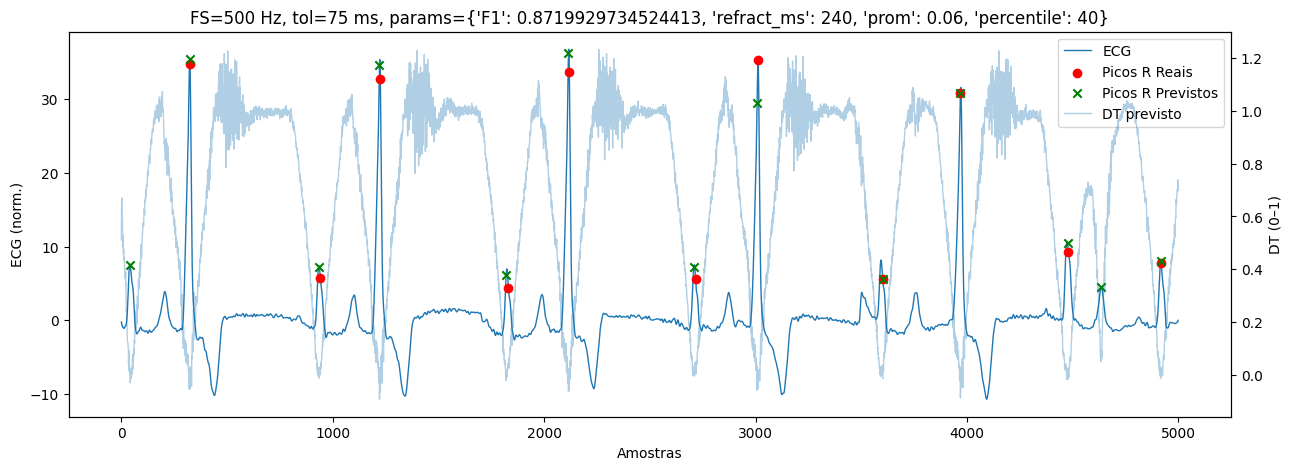

In [ ]:
# -*- coding: utf-8 -*-
"""
Detecção de picos R (ECG 5000x1) com U-Net 1D estilo RPNet + melhorias:
- Pré-proc: remove spikes, passa-banda 0.5–40 Hz, normalização robusta
- Rótulo: Distance Transform (DT) (clip 120 amostras ~ 240 ms)
- Modelo: U-Net 1D com blocos Inception-Residual + crop nas skips
- Treino: Huber + sample_weight por timestep (foco nos vales do DT)
- Pós-proc: detecção adaptativa (prominence + percentil + NMS)
- Tuning automático de hyperparams de detecção para maximizar F1 na validação
- Plot: ECG + picos reais/previstos + DT (duas escalas) com legenda correta
"""

import os
import numpy as np
from scipy import io
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import distance_transform_edt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt

# -------------------- Parâmetros --------------------
FS = 500
WIN_SAMPLES = 5000
REFRACT_MS_DEFAULT = 200
TOL_MS = 75
REFRACT_SAMPLES_DEFAULT = int(REFRACT_MS_DEFAULT * FS / 1000)
TOL_SAMPLES = int(TOL_MS * FS / 1000)

EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-3

# Colab Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

ECG_PATH = '/content/drive/My Drive/Dataset_PicoR/data'
RPEAK_PATH = '/content/drive/My Drive/Dataset_PicoR/ref'
SAVE_MODEL_PATH = '/content/drive/My Drive/Dataset_PicoR/cnn_ecg_treinado.keras'

# -------------------- Utils de sinal --------------------
def remove_spikes(x, threshold=20.0):
    x = np.asarray(x, dtype=np.float32).copy()
    idx = np.where(x > threshold)[0]
    for i in idx:
        if i > 0:
            x[i] = x[i-1]
    return x

def bandpass_filter(x, fs=FS, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='bandpass')
    return filtfilt(b, a, x).astype(np.float32)

def robust_normalize(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    return (x - med) / mad

def pad_or_trim_to_length(x, length):
    x = np.asarray(x).flatten()
    if len(x) == length: return x
    if len(x) > length:  return x[:length]
    out = np.zeros(length, dtype=x.dtype); out[:len(x)] = x
    return out

# -------------------- Rótulo DT --------------------
def make_dt_label(length, rpeaks_idx, clip_samples=120):
    mask = np.zeros(length, dtype=bool)
    r = np.asarray(rpeaks_idx, dtype=int)
    r = r[(r >= 0) & (r < length)]
    mask[r] = True
    dt = distance_transform_edt(~mask).astype(np.float32)
    dt = np.clip(dt, 0, clip_samples) / float(clip_samples)  # 0..1
    return dt

# -------------------- Modelo --------------------
def conv_block(x, filters, k=3):
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(negative_slope=0.2)(x)

def inception_res_block(x, filters):
    b1 = conv_block(x, filters//4, k=15)
    b2 = conv_block(x, filters//4, k=17)
    b3 = conv_block(x, filters//4, k=19)
    b4 = conv_block(x, filters//4, k=21)
    y  = layers.Concatenate()([b1, b2, b3, b4])
    y  = layers.Conv1D(filters, 1, padding="same")(y)
    y  = layers.BatchNormalization()(y)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    y  = layers.Add()([x, y])
    return layers.LeakyReLU(negative_slope=0.2)(y)

def crop_decoder_to_encoder(dec, enc):
    def _crop(args):
        d, e = args
        d_len = tf.shape(d)[1]
        e_len = tf.shape(e)[1]
        start = tf.maximum((d_len - e_len) // 2, 0)
        return d[:, start:start + e_len, :]
    return layers.Lambda(_crop)([dec, enc])

def build_unet1d(input_len=WIN_SAMPLES):
    inp = Input(shape=(input_len, 1))
    # Encoder
    e1 = inception_res_block(inp, 64);   p1 = layers.Conv1D(64, 4, strides=2, padding="same")(e1)   # 5000->2500
    e2 = inception_res_block(p1, 128);   p2 = layers.Conv1D(128,4, strides=2, padding="same")(e2)   # 2500->1250
    e3 = inception_res_block(p2, 256);   p3 = layers.Conv1D(256,4, strides=2, padding="same")(e3)   # 1250->625
    e4 = inception_res_block(p3, 512);   p4 = layers.Conv1D(512,4, strides=2, padding="same")(e4)   # 625->313

    b  = inception_res_block(p4, 512)

    # Decoder (corta decoder para bater com encoder)
    u4 = layers.Conv1DTranspose(512,4, strides=2, padding="same")(b)    # 313->626
    u4 = crop_decoder_to_encoder(u4, e4); u4 = layers.Concatenate()([u4, e4]); u4 = inception_res_block(u4, 512)  # 625
    u3 = layers.Conv1DTranspose(256,4, strides=2, padding="same")(u4)   # 625->1250
    u3 = crop_decoder_to_encoder(u3, e3); u3 = layers.Concatenate()([u3, e3]); u3 = inception_res_block(u3, 256)  # 1250
    u2 = layers.Conv1DTranspose(128,4, strides=2, padding="same")(u3)   # 1250->2500
    u2 = crop_decoder_to_encoder(u2, e2); u2 = layers.Concatenate()([u2, e2]); u2 = inception_res_block(u2, 128)  # 2500
    u1 = layers.Conv1DTranspose(64, 4, strides=2, padding="same")(u2)   # 2500->5000
    u1 = crop_decoder_to_encoder(u1, e1); u1 = layers.Concatenate()([u1, e1]); u1 = inception_res_block(u1, 64)   # 5000

    out = layers.Conv1D(1, 1, padding="same", activation="linear")(u1)  # (5000,1)
    return Model(inp, out, name="UNet1D_DT")

# -------------------- Loader --------------------
def _sanitize_rpeaks(rpeaks, length):
    r = np.asarray(rpeaks).astype(float).flatten()
    r = r[~np.isnan(r)].astype(int)
    # heurística 1-based -> 0-based somente se necessário
    if r.size > 0 and r.min() >= 1 and r.max() <= length and (r.max() == length):
        r = r - 1
    r = r[(r >= 0) & (r < length)]
    return np.unique(r)

def load_dataset(ecg_path, rpeak_path):
    x_data, y_dt, peaks_list = [], [], []
    ecg_files = sorted([f for f in os.listdir(ecg_path) if f.endswith(".mat")])
    rpk_files = sorted([f for f in os.listdir(rpeak_path) if f.endswith(".mat")])
    assert len(ecg_files) == len(rpk_files), "Nº de ECGs e R_peak não bate."

    for ecg_file, r_file in zip(ecg_files, rpk_files):
        m_ecg = io.loadmat(os.path.join(ecg_path, ecg_file))
        m_rpk = io.loadmat(os.path.join(rpeak_path, r_file))

        ecg = np.asarray(m_ecg.get('ecg')).astype(np.float32).squeeze()
        if 'R_peak' in m_rpk: r_raw = m_rpk['R_peak']
        elif 'R' in m_rpk:    r_raw = m_rpk['R']
        else: raise KeyError(f"Nenhuma variável 'R_peak' ou 'R' em {r_file}")

        rpeaks = _sanitize_rpeaks(r_raw, len(ecg))

        ecg = pad_or_trim_to_length(ecg, WIN_SAMPLES)
        rpeaks = rpeaks[(rpeaks >= 0) & (rpeaks < WIN_SAMPLES)]

        ecg = remove_spikes(ecg)
        ecg = bandpass_filter(ecg, fs=FS, low=0.5, high=40.0, order=4)
        ecg = robust_normalize(ecg)

        dt = make_dt_label(WIN_SAMPLES, rpeaks, clip_samples=120)

        x_data.append(ecg.reshape(-1,1))
        y_dt.append(dt.reshape(-1,1))
        peaks_list.append(rpeaks)

    X = np.asarray(x_data, dtype=np.float32)
    Y = np.asarray(y_dt, dtype=np.float32)
    return X, Y, peaks_list

# -------------------- Pós-proc (detector adaptativo) --------------------
def detect_r_from_dt(dt_pred, fs=FS, refract_ms=220, prom=0.08, percentile=50, adaptive=True):
    """
    dt_pred: (N,) em [0,1]; buscamos vales => picos no sinal x = -dt_pred
    adaptive: além de 'prominence', aplica limiar por percentil nos vales encontrados
    """
    refract = int(refract_ms * fs / 1000)
    x = -dt_pred
    peaks, _ = find_peaks(x, distance=refract, prominence=prom)

    if adaptive and peaks.size:
        vals = x[peaks]
        thr = np.percentile(vals, percentile)  # 40..60 típico
        keep = vals >= thr
        peaks = peaks[keep]

    # NMS simples: mescla picos muito próximos escolhendo o vale mais fundo
    if peaks.size > 1:
        merged = [peaks[0]]
        for p in peaks[1:]:
            if p - merged[-1] < refract:
                if x[p] > x[merged[-1]]:
                    merged[-1] = p
            else:
                merged.append(p)
        peaks = np.array(merged, dtype=int)

    return peaks

# -------------------- Métrica com tolerância --------------------
def prf_with_tolerance(r_true, r_pred, tol=TOL_SAMPLES):
    r_true = np.asarray(sorted(set([int(v) for v in r_true])))
    r_pred = np.asarray(sorted(set([int(v) for v in r_pred])))
    if len(r_true) == 0 and len(r_pred) == 0: return 1.0, 1.0, 1.0
    if len(r_pred) == 0: return 0.0, 0.0, 0.0

    tp = 0; used = set(); j = 0
    for i in range(len(r_true)):
        while j < len(r_pred) and r_pred[j] < r_true[i] - tol: j += 1
        k = j
        while k < len(r_pred) and r_pred[k] <= r_true[i] + tol:
            if k not in used:
                used.add(k); tp += 1; break
            k += 1
    fp = len(r_pred) - tp
    fn = len(r_true) - tp
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2*prec*rec / (prec + rec + 1e-9)
    return float(prec), float(rec), float(f1)

# -------------------- Tuning automático no conjunto de validação --------------------
def tune_detector_params(dt_preds, peaks_val, fs=FS):
    """
    Busca em grade parâmetros que maximizam F1 médio na validação.
    Retorna dict com melhores: refract_ms, prom, percentile.
    """
    refracts = [200, 220, 240]
    proms =    [0.06, 0.08, 0.10]
    percs =    [40, 50, 60]

    best = {"F1": -1, "refract_ms": None, "prom": None, "percentile": None}
    for rm in refracts:
        for pr in proms:
            for pc in percs:
                P, R, F = [], [], []
                for n in range(len(dt_preds)):
                    dt_pred = dt_preds[n]
                    r_est = detect_r_from_dt(dt_pred, fs=fs, refract_ms=rm, prom=pr, percentile=pc, adaptive=True)
                    r_true = peaks_val[n]
                    p, r, f1 = prf_with_tolerance(r_true, r_est)
                    P.append(p); R.append(r); F.append(f1)
                meanF1 = float(np.mean(F))
                if meanF1 > best["F1"]:
                    best = {"F1": meanF1, "refract_ms": rm, "prom": pr, "percentile": pc}
    return best

# -------------------- Visualização --------------------
def plot_prediction(idx, X_split, peaks_split, dt_pred, params, title=None):
    ecg_signal = X_split[idx].squeeze()
    r_true = peaks_split[idx]
    r_pred = detect_r_from_dt(dt_pred[idx], fs=FS,
                              refract_ms=params["refract_ms"],
                              prom=params["prom"],
                              percentile=params["percentile"],
                              adaptive=True)

    fig, ax1 = plt.subplots(figsize=(15,5))
    l1, = ax1.plot(ecg_signal, label="ECG", lw=1.0)
    if len(r_true) > 0:
        s1 = ax1.scatter(r_true, ecg_signal[r_true], color='red', label='Picos R Reais', zorder=3)
    if len(r_pred) > 0:
        s2 = ax1.scatter(r_pred, ecg_signal[r_pred], color='green', marker='x', label='Picos R Previstos', zorder=3)

    ax2 = ax1.twinx()
    l2, = ax2.plot(dt_pred[idx], alpha=0.35, lw=1.0, label='DT previsto')

    h1, l_1 = ax1.get_legend_handles_labels()
    h2, l_2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l_1+l_2, loc='upper right')

    ax1.set_xlabel("Amostras")
    ax1.set_ylabel("ECG (norm.)")
    ax2.set_ylabel("DT (0–1)")
    ax1.set_title(title or f"FS={FS} Hz, tol={TOL_MS} ms")
    plt.show()

# -------------------- Main --------------------
def main():
    print("Carregando dados...")
    X, Y_dt, peaks_true = load_dataset(ECG_PATH, RPEAK_PATH)
    print(f"X: {X.shape}, Y_dt: {Y_dt.shape}, registros: {len(peaks_true)}")

    idx = np.arange(len(X))
    X_train, X_val, Y_train, Y_val, idx_train, idx_val = train_test_split(
        X, Y_dt, idx, test_size=0.2, random_state=42, shuffle=True
    )
    peaks_val = [peaks_true[i] for i in idx_val]

    # Pesos por timestep: 1/(DT+eps) -> mais peso perto dos picos
    eps = 1e-3
    W_train = (1.0 / (Y_train.squeeze(-1) + eps)).astype(np.float32)
    W_val   = (1.0 / (Y_val.squeeze(-1)   + eps)).astype(np.float32)
    # precisa ter shape (N, T, 1) ou (N, T) para broadcasting correto
    W_train = W_train[..., np.newaxis]
    W_val   = W_val[..., np.newaxis]

    model = build_unet1d(WIN_SAMPLES)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR),
                  loss=tf.keras.losses.Huber())

    cbs = [
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=8, verbose=1, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(SAVE_MODEL_PATH, monitor='val_loss',
                                           save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                         restore_best_weights=True, verbose=1),
    ]

    print("Treinando...")
    model.fit(X_train, Y_train,
              sample_weight=W_train,                    # pesos por timestep (broadcast com (N,T,1))
              validation_data=(X_val, Y_val, W_val),    # mantém coerência do val_loss
              epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cbs, verbose=1)

    model.save(SAVE_MODEL_PATH)
    print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")

    # Inferência no conjunto de validação (para tuning do detector)
    print("Gerando DT previstos na validação...")
    y_pred_dt = model.predict(X_val, batch_size=64, verbose=0)  # (N,5000,1)
    dt_preds = [y_pred_dt[n, :, 0] for n in range(len(X_val))]

    print("Fazendo auto-tuning dos parâmetros de detecção...")
    best = tune_detector_params(dt_preds, peaks_val, fs=FS)
    print(f"🔧 Melhores params: refrat={best['refract_ms']} ms, prom={best['prom']:.3f}, pct={best['percentile']} "
          f"(F1 médio={best['F1']:.4f})")

    # Avaliação final usando os melhores parâmetros
    print("Avaliando com os melhores parâmetros de detecção...")
    precisions, recalls, f1s = [], [], []
    for n in range(len(X_val)):
        r_est = detect_r_from_dt(dt_preds[n], fs=FS,
                                 refract_ms=best["refract_ms"],
                                 prom=best["prom"],
                                 percentile=best["percentile"],
                                 adaptive=True)
        r_true = peaks_val[n]
        p, r, f1 = prf_with_tolerance(r_true, r_est, tol=TOL_SAMPLES)
        precisions.append(p); recalls.append(r); f1s.append(f1)

    print(f"📈 Val (tuned) — Precision: {np.mean(precisions):.4f}  Recall: {np.mean(recalls):.4f}  F1: {np.mean(f1s):.4f}")

    # Plot exemplo
    plot_prediction(idx=0, X_split=X_val, peaks_split=peaks_val,
                    dt_pred=dt_preds, params=best,
                    title=f"FS={FS} Hz, tol={TOL_MS} ms, params={best}")

if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Carregado: 200 registros | X: (200, 5000, 1)  Y: (200, 5000, 1)
✅ Médias salvas em: /content/drive/My Drive/onda_T/means_ton.npy
Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 210s 41s/step - binary_accuracy: 0.4935 - loss: 0.7273 - val_binary_accuracy: 0.5654 - val_loss: 0.5902 - learning_rate: 1.0000e-04
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6122 - loss: 0.3534 - val_binary_accuracy: 0.5933 - val_loss: 0.5484 - learning_rate: 1.0000e-04
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6202 - loss: 0.2479 - val_binary_accuracy: 0.5971 - val_loss: 0.5160 - learning_rate: 1.0000e-04
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - binary_accuracy: 0.6143 - loss: 0.2045 - val_binary_accuracy: 0.6059 - val_loss: 0.4724 - learning_rate: 1.0000e-04
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6134 - lo

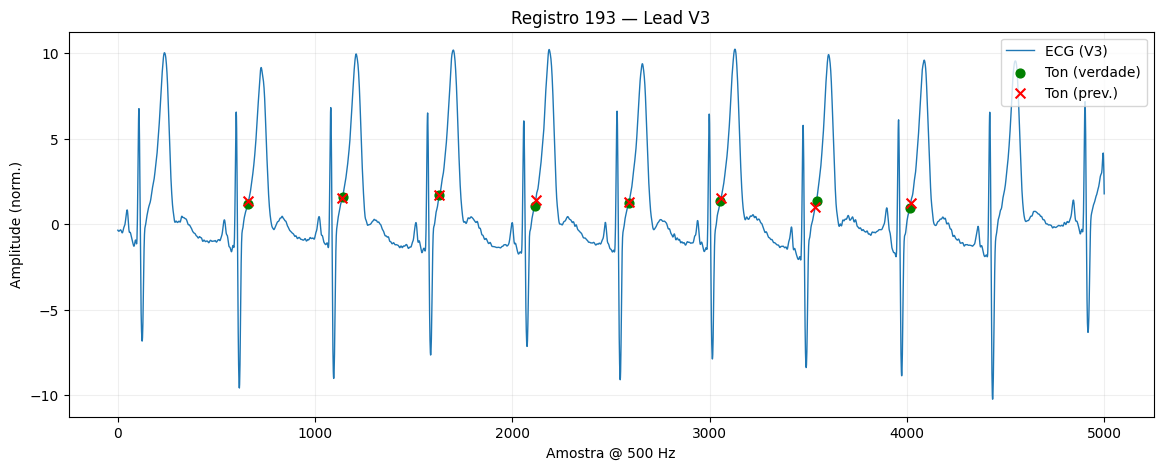

In [ ]:
# ================== Colab: Detector de T-onset (LUDB) — CORRIGIDO ==================
# Dependência (roda uma vez por sessão):
!pip -q install wfdb

import os, numpy as np, matplotlib.pyplot as plt
import wfdb
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from scipy.signal import find_peaks, butter, filtfilt
from google.colab import drive

# -------------------- Parâmetros principais --------------------
drive.mount('/content/drive')

ROOT = "/content/drive/My Drive/onda_T/data"   # << seu caminho
LEAD = "V3"                                     # troque para "V5" se preferir
FS = 500
WIN_SAMPLES = 5000          # LUDB = 10 s @ 500 Hz
SIGMA_MS = 15               # largura do alvo (gauss) ~12–20 ms
TOL_MS = 30                 # tolerância p/ casar Ton previsto vs real
USE_R_GATING = True         # usar janela fisiológica por batimento baseada em R
FALLBACK_LEAD = "V5"        # fallback automático se V3 não tiver Ton

SAVE_MODEL_PATH = "/content/drive/My Drive/onda_T/cnn_ton_unet.keras"
SAVE_MEANS_PATH = "/content/drive/My Drive/onda_T/means_ton.npy"
os.makedirs(os.path.dirname(SAVE_MODEL_PATH), exist_ok=True)

# -------------------- Pré-processamento --------------------
def remove_spikes(x, threshold=20.0):
    x = np.asarray(x, dtype=np.float32).copy()
    idx = np.where(x > threshold)[0]
    for i in idx:
        if i > 0: x[i] = x[i-1]
    return x

def bandpass_filter(x, fs=FS, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='bandpass')
    return filtfilt(b, a, x).astype(np.float32)

def robust_normalize(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + eps
    return (x - med) / mad

# -------------------- Alvo: mapa gaussiano em Ton --------------------
def gaussian_map(length, centers, sigma_ms=15, fs=500):
    y = np.zeros(length, dtype=np.float32)
    if centers is None or len(centers) == 0:
        return y
    sigma = max(1, int(round((sigma_ms/1000.0)*fs)))
    x = np.arange(length)
    for c in centers:
        if 0 <= c < length:
            y += np.exp(-0.5 * ((x - c) / sigma)**2).astype(np.float32)
    # normaliza para [0,1]
    y = (y - y.min()) / (y.max() - y.min() + 1e-8)
    return y

# -------------------- Parser de anotações LUDB (corrigido) --------------------
def parse_t_annotations(ann):
    """
    Extrai Ton, T-peak e Toff do LUDB usando symbol:
      '(' antes de 't'  -> Ton
      't'               -> T-peak
      ')' após 't'      -> Toff
    R-peaks: 'N' (ou 'R')
    """
    Ton, Tpk, Toff, R = [], [], [], []
    samp = np.asarray(ann.sample, dtype=int)
    symb = list(ann.symbol)

    last_onset = None
    saw_t = False
    for s, sb in zip(samp, symb):
        if sb == "(":
            last_onset = s
            saw_t = False
        elif sb.lower() == "t":
            Tpk.append(int(s))
            # se houve '(' imediatamente antes deste 't', esse '(' é o Ton
            if last_onset is not None:
                Ton.append(int(last_onset))
                last_onset = None
            saw_t = True
        elif sb == ")":
            # fecha T se o último pico foi T
            if saw_t:
                Toff.append(int(s))
                saw_t = False
        elif sb.upper() in ("N", "R"):
            R.append(int(s))

    return np.array(Ton, int), np.array(Tpk, int), np.array(Toff, int), np.array(R, int)

def list_records(root):
    return sorted([os.path.splitext(f)[0] for f in os.listdir(root) if f.endswith(".hea")])

# -------------------- Loader LUDB -> X, Y (com fallback V3→V5) --------------------
def load_ludb_dataset(root, lead="V3", fs=500, fallback_lead="V5"):
    X, Y, means, meta = [], [], [], []
    recs = list_records(root)
    if not recs:
        raise RuntimeError(f"Nenhum .hea encontrado em {root}")

    primary = lead.upper()
    fallback = fallback_lead.upper() if fallback_lead else None

    for rec in recs:
        base = os.path.join(root, rec)
        # Sinal
        sig, fields = wfdb.rdsamp(base)  # fields é dict
        names = [n.upper() for n in fields['sig_name']]

        def get_lead_signal(name):
            if name.upper() not in names:
                return None
            col = names.index(name.upper())
            return sig[:, col].astype(np.float32)

        # Tenta lead primária
        use_lead = primary
        ecg = get_lead_signal(primary)
        ann = None
        Ton = Tpk = Toff = R = np.array([], int)

        if ecg is not None:
            try:
                ann = wfdb.rdann(base, primary.lower())
                Ton, Tpk, Toff, R = parse_t_annotations(ann)
            except Exception:
                ann = None

        # Se não encontrou Ton na primária, tenta fallback (ex.: V5)
        if (Ton.size == 0) and fallback:
            ecg_fb = get_lead_signal(fallback)
            if ecg_fb is not None:
                try:
                    ann_fb = wfdb.rdann(base, fallback.lower())
                    Ton_fb, Tpk_fb, Toff_fb, R_fb = parse_t_annotations(ann_fb)
                    if Ton_fb.size > 0:
                        ecg, ann, use_lead = ecg_fb, ann_fb, fallback
                        Ton, Tpk, Toff, R = Ton_fb, Tpk_fb, Toff_fb, R_fb
                except Exception:
                    pass

        if Ton.size == 0 or ecg is None:
            print(f"[aviso] {rec}.{primary}: sem Ton; fallback {fallback} não ajudou. Pulando.")
            continue

        # Pré-processamento
        ecg = remove_spikes(ecg)
        m = float(np.mean(ecg)); means.append(m)
        ecg = ecg - m
        ecg = bandpass_filter(ecg, fs=fs, low=0.5, high=40.0)
        ecg = robust_normalize(ecg)

        # Alvo gaussiano nos Ton
        y = gaussian_map(len(ecg), Ton, sigma_ms=SIGMA_MS, fs=fs)

        X.append(ecg.reshape(-1,1))                     # (5000,1)
        Y.append(y.reshape(-1,1))                       # (5000,1)
        meta.append({"rec": rec, "Ton": Ton, "R": R, "lead": use_lead})

    if not X:
        raise RuntimeError("Nada carregado (verifique pasta/lead/arquivos de anotação).")
    return np.array(X), np.array(Y), np.array(means), meta

# -------------------- Modelo U-Net 1D (seu estilo) --------------------
def conv_block(x, filters, k=3):
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(negative_slope=0.2)(x)

def inception_res_block(x, filters):
    b1 = conv_block(x, filters//4, k=15)
    b2 = conv_block(x, filters//4, k=17)
    b3 = conv_block(x, filters//4, k=19)
    b4 = conv_block(x, filters//4, k=21)
    y  = layers.Concatenate()([b1, b2, b3, b4])
    y  = layers.Conv1D(filters, 1, padding="same")(y)
    y  = layers.BatchNormalization()(y)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    y  = layers.Add()([x, y])
    return layers.LeakyReLU(negative_slope=0.2)(y)

def crop_decoder_to_encoder(dec, enc):
    def _crop(args):
        d, e = args
        d_len = tf.shape(d)[1]
        e_len = tf.shape(e)[1]
        start = tf.maximum((d_len - e_len) // 2, 0)
        return d[:, start:start + e_len, :]
    return layers.Lambda(_crop)([dec, enc])

def build_unet1d(input_len=WIN_SAMPLES):
    inp = Input(shape=(input_len, 1))
    # Encoder
    e1 = inception_res_block(inp, 64);   p1 = layers.Conv1D(64, 4, strides=2, padding="same")(e1)   # 5000->2500
    e2 = inception_res_block(p1, 128);   p2 = layers.Conv1D(128,4, strides=2, padding="same")(e2)   # 2500->1250
    e3 = inception_res_block(p2, 256);   p3 = layers.Conv1D(256,4, strides=2, padding="same")(e3)   # 1250->625
    e4 = inception_res_block(p3, 512);   p4 = layers.Conv1D(512,4, strides=2, padding="same")(e4)   # 625->313

    b  = inception_res_block(p4, 512)

    # Decoder
    u4 = layers.Conv1DTranspose(512,4, strides=2, padding="same")(b)    # 313->626
    u4 = crop_decoder_to_encoder(u4, e4); u4 = layers.Concatenate()([u4, e4]); u4 = inception_res_block(u4, 512)  # ~625
    u3 = layers.Conv1DTranspose(256,4, strides=2, padding="same")(u4)   # ~625->~1250
    u3 = crop_decoder_to_encoder(u3, e3); u3 = layers.Concatenate()([u3, e3]); u3 = inception_res_block(u3, 256)
    u2 = layers.Conv1DTranspose(128,4, strides=2, padding="same")(u3)   # ~1250->~2500
    u2 = crop_decoder_to_encoder(u2, e2); u2 = layers.Concatenate()([u2, e2]); u2 = inception_res_block(u2, 128)
    u1 = layers.Conv1DTranspose(64, 4, strides=2, padding="same")(u2)   # ~2500->~5000
    u1 = crop_decoder_to_encoder(u1, e1); u1 = layers.Concatenate()([u1, e1]); u1 = inception_res_block(u1, 64)

    # Mapa [0,1] de probabilidade de Ton
    out = layers.Conv1D(1, 1, padding="same", activation="sigmoid")(u1)
    return Model(inp, out, name="UNet1D_Ton")

# -------------------- Detecção de Ton no mapa previsto --------------------
def pick_ton_from_map(y_pred, R=None, fs=FS, min_dist_ms=120, rr_frac_max=0.6, thr=0.5):
    """
    Se houver R: para cada batimento, pega o maior pico em [R+120ms, R+0.6*RR].
    Senão: picos globais com distância mínima.
    """
    if R is None or len(R) < 2:
        peaks, _ = find_peaks(y_pred, height=thr, distance=int((min_dist_ms/1000.0)*fs))
        return peaks.astype(int)

    preds = []
    R = np.asarray(R, int)
    for i in range(len(R)-1):
        a = R[i] + int(round((min_dist_ms/1000.0)*fs))
        b = R[i] + int(round(rr_frac_max * (R[i+1] - R[i])))
        a = max(0, a); b = min(len(y_pred)-1, b)
        if b <= a:
            continue
        seg = y_pred[a:b+1]
        if seg.size == 0:
            continue
        k = int(np.argmax(seg))
        if seg[k] >= thr:
            preds.append(a + k)
    return np.array(preds, dtype=int)

def match_prf(pred_idx, true_idx, tol_ms=TOL_MS, fs=FS):
    tol = int(round((tol_ms/1000.0)*fs))
    pred_idx = np.array(sorted(set([int(p) for p in pred_idx])), dtype=int)
    true_idx = np.array(sorted(set([int(t) for t in true_idx])), dtype=int)
    if len(true_idx) == 0 and len(pred_idx) == 0: return 1.0, 1.0, 1.0
    if len(pred_idx) == 0: return 0.0, 0.0, 0.0
    TP = 0; used = np.zeros(len(true_idx), dtype=bool)
    for p in pred_idx:
        for j,t in enumerate(true_idx):
            if used[j]:
                continue
            if abs(p - t) <= tol:
                TP += 1; used[j] = True; break
    FP = max(0, len(pred_idx) - TP)
    FN = max(0, len(true_idx) - TP)
    prec = TP / (TP + FP + 1e-8)
    rec  = TP / (TP + FN + 1e-8)
    f1   = 2*prec*rec / (prec+rec+1e-8)
    return float(prec), float(rec), float(f1)

# -------------------- Treino + Avaliação --------------------
X, Y, means, meta = load_ludb_dataset(ROOT, lead=LEAD, fs=FS, fallback_lead=FALLBACK_LEAD)
np.save(SAVE_MEANS_PATH, means)
print(f"✅ Carregado: {X.shape[0]} registros | X: {X.shape}  Y: {Y.shape}")
print(f"✅ Médias salvas em: {SAVE_MEANS_PATH}")

X_train, X_val, Y_train, Y_val, meta_train, meta_val = train_test_split(
    X, Y, meta, test_size=0.2, random_state=42, shuffle=True
)

# Pesos por timestep (enfatiza região perto do Ton)
W_train = (1.0 + 4.0*Y_train).astype(np.float32)
W_val   = (1.0 + 4.0*Y_val  ).astype(np.float32)

model = build_unet1d(WIN_SAMPLES)
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["binary_accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ModelCheckpoint(SAVE_MODEL_PATH, monitor="val_loss", save_best_only=True)
]

hist = model.fit(
    X_train, Y_train,
    sample_weight=W_train,
    validation_data=(X_val, Y_val, W_val),
    epochs=80, batch_size=64, callbacks=callbacks, verbose=1
)

print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")

# -------------------- Avaliação no conjunto de validação --------------------
prec_all, rec_all, f1_all = [], [], []
for x, info in zip(X_val, meta_val):
    yhat = model.predict(x[None, ...], verbose=0)[0,:,0]      # (5000,)
    R = info["R"] if (USE_R_GATING and len(info["R"])>1) else None
    pred_ton = pick_ton_from_map(yhat, R=R, fs=FS, min_dist_ms=120, rr_frac_max=0.6, thr=0.5)
    p, r, f1 = match_prf(pred_ton, info["Ton"], tol_ms=TOL_MS, fs=FS)
    prec_all.append(p); rec_all.append(r); f1_all.append(f1)

print(f"📈 Val — Precision: {np.nanmean(prec_all):.4f}  Recall: {np.nanmean(rec_all):.4f}  F1: {np.nanmean(f1_all):.4f}")

# -------------------- Plot de um exemplo --------------------
idx = np.random.randint(0, len(X_val))
x = X_val[idx][:,0]
info = meta_val[idx]
yhat = model.predict(X_val[idx][None, ...], verbose=0)[0,:,0]
R = info["R"] if (USE_R_GATING and len(info["R"])>1) else None
pred_ton = pick_ton_from_map(yhat, R=R, fs=FS, min_dist_ms=120, rr_frac_max=0.6, thr=0.5)

plt.figure(figsize=(14,5))
plt.plot(x, label=f"ECG ({info['lead']})", lw=1)  # já normalizado
plt.scatter(info["Ton"], x[info["Ton"]], color="green", s=40, label="Ton (verdade)", zorder=3)
if len(pred_ton):
    plt.scatter(pred_ton, x[pred_ton], color="red", marker="x", s=50, label="Ton (prev.)", zorder=3)
plt.title(f"Registro {info['rec']} — Lead {info['lead']}")
plt.xlabel("Amostra @ 500 Hz"); plt.ylabel("Amplitude (norm.)")
plt.legend(loc="upper right")
plt.grid(alpha=0.2)
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Carregado: 200 registros | X: (200, 5000, 2)  Y: (200, 5000, 1)
Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 85s 15s/step - binary_accuracy: 0.4092 - loss: 0.8587 - val_binary_accuracy: 0.5205 - val_loss: 0.6176 - learning_rate: 1.0000e-04
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6056 - loss: 0.3999 - val_binary_accuracy: 0.5657 - val_loss: 0.5394 - learning_rate: 1.0000e-04
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - binary_accuracy: 0.6137 - loss: 0.2600 - val_binary_accuracy: 0.5861 - val_loss: 0.4629 - learning_rate: 1.0000e-04
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6124 - loss: 0.2115 - val_binary_accuracy: 0.6019 - val_loss: 0.3940 - learning_rate: 1.0000e-04
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - binary_accuracy: 0.6157 - loss: 0.1904 - val_binary_accuracy: 0.6096 - val_loss: 0.3216 - lear

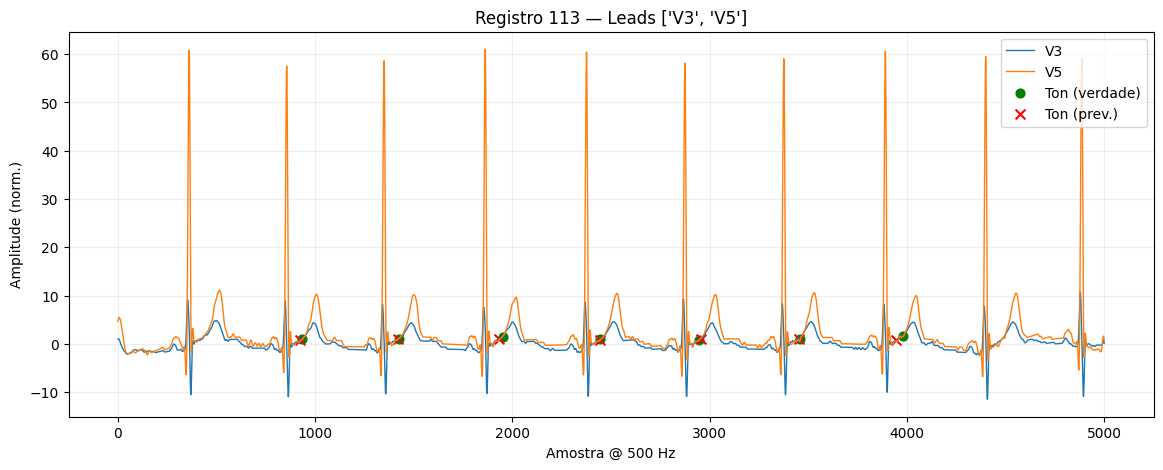

In [ ]:
# ================== Colab: Detector de T-onset (LUDB) — MULTI-LEAD V3+V5 ==================
!pip -q install wfdb

import os, numpy as np, matplotlib.pyplot as plt, wfdb, tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from scipy.signal import find_peaks, butter, filtfilt
from google.colab import drive

# -------------------- Parâmetros --------------------
drive.mount('/content/drive')

ROOT = "/content/drive/My Drive/onda_T/data"   # sua pasta LUDB
LEADS = ["V3","V5"]                             # 2 canais
FS = 500
WIN_SAMPLES = 5000
SIGMA_MS = 15
TOL_MS = 30
USE_R_GATING = True

SAVE_MODEL_PATH = "/content/drive/My Drive/onda_T/cnn_ton_unet_V3V5.keras"

# -------------------- Pré-proc --------------------
def remove_spikes(x, threshold=20.0):
    x = np.asarray(x, dtype=np.float32).copy()
    idx = np.where(x > threshold)[0]
    for i in idx:
        if i > 0: x[i] = x[i-1]
    return x

def bandpass_filter(x, fs=FS, low=0.5, high=40.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='bandpass')
    return filtfilt(b, a, x).astype(np.float32)

def robust_normalize(x, eps=1e-6):
    med = np.median(x); mad = np.median(np.abs(x - med)) + eps
    return (x - med) / mad

# -------------------- Alvo --------------------
def gaussian_map(length, centers, sigma_ms=15, fs=500):
    y = np.zeros(length, dtype=np.float32)
    if centers is None or len(centers) == 0: return y
    sigma = max(1, int(round((sigma_ms/1000.0)*fs)))
    x = np.arange(length)
    for c in centers:
        if 0 <= c < length: y += np.exp(-0.5 * ((x - c) / sigma)**2).astype(np.float32)
    return (y - y.min()) / (y.max() - y.min() + 1e-8)

# -------------------- Parser LUDB (por symbol) --------------------
def parse_t_annotations(ann):
    Ton, Tpk, Toff, R = [], [], [], []
    samp = np.asarray(ann.sample, dtype=int)
    symb = list(ann.symbol)
    last_onset, saw_t = None, False
    for s, sb in zip(samp, symb):
        if sb == "(":
            last_onset = s; saw_t = False
        elif sb.lower() == "t":
            Tpk.append(int(s))
            if last_onset is not None:
                Ton.append(int(last_onset)); last_onset = None
            saw_t = True
        elif sb == ")":
            if saw_t:
                Toff.append(int(s)); saw_t = False
        elif sb.upper() in ("N","R"):
            R.append(int(s))
    return np.array(Ton,int), np.array(Tpk,int), np.array(Toff,int), np.array(R,int)

def list_records(root):
    return sorted([os.path.splitext(f)[0] for f in os.listdir(root) if f.endswith(".hea")])

# -------------------- Loader MULTI (V3+V5) --------------------
def load_ludb_multi(root, leads=("V3","V5"), fs=500):
    X, Y, meta = [], [], []
    recs = list_records(root)
    if not recs: raise RuntimeError(f"Nenhum .hea em {root}")
    for rec in recs:
        base = os.path.join(root, rec)
        sig, fields = wfdb.rdsamp(base)
        names = [n.upper() for n in fields['sig_name']]

        # checar se ambas as leads existem
        if not all(ld.upper() in names for ld in leads):
            continue

        cols = [names.index(ld.upper()) for ld in leads]
        ecgs = sig[:, cols].astype(np.float32)            # (5000,2)

        # anotação: pegue de qualquer uma das duas (mesma temporização)
        ann = None
        for ld in leads:
            try:
                ann = wfdb.rdann(base, ld.lower()); break
            except Exception:
                ann = None
        if ann is None: continue

        Ton, Tpk, Toff, R = parse_t_annotations(ann)
        if Ton.size == 0: continue

        # pré-proc por canal
        for c in range(ecgs.shape[1]):
            ecgs[:,c] = remove_spikes(ecgs[:,c])
            ecgs[:,c] = ecgs[:,c] - float(np.mean(ecgs[:,c]))
            ecgs[:,c] = bandpass_filter(ecgs[:,c], fs=fs, low=0.5, high=40.0)
            ecgs[:,c] = robust_normalize(ecgs[:,c])

        y = gaussian_map(ecgs.shape[0], Ton, sigma_ms=SIGMA_MS, fs=fs)  # (5000,)

        X.append(ecgs)                            # (5000,2)
        Y.append(y[:,None])                       # (5000,1)
        meta.append({"rec": rec, "Ton": Ton, "R": R, "leads": leads})
    if not X: raise RuntimeError("Nada carregado (cheque pasta/leads).")
    return np.array(X), np.array(Y), meta

# -------------------- Modelo (U-Net 1D; input 2 canais) --------------------
def conv_block(x, filters, k=3):
    x = layers.Conv1D(filters, k, padding="same")(x)
    x = layers.BatchNormalization()(x)
    return layers.LeakyReLU(0.2)(x)

def inception_res_block(x, filters):
    b1 = conv_block(x, filters//4, k=15)
    b2 = conv_block(x, filters//4, k=17)
    b3 = conv_block(x, filters//4, k=19)
    b4 = conv_block(x, filters//4, k=21)
    y  = layers.Concatenate()([b1,b2,b3,b4])
    y  = layers.Conv1D(filters, 1, padding="same")(y)
    y  = layers.BatchNormalization()(y)
    if x.shape[-1] != filters:
        x = layers.Conv1D(filters, 1, padding="same")(x)
    y  = layers.Add()([x,y])
    return layers.LeakyReLU(0.2)(y)

def crop_decoder_to_encoder(dec, enc):
    def _crop(args):
        d,e = args
        d_len = tf.shape(d)[1]; e_len = tf.shape(e)[1]
        start = tf.maximum((d_len - e_len)//2, 0)
        return d[:, start:start+e_len, :]
    return layers.Lambda(_crop)([dec,enc])

def build_unet1d(input_len=WIN_SAMPLES, n_channels=2):
    inp = Input(shape=(input_len, n_channels))
    e1 = inception_res_block(inp, 64);   p1 = layers.Conv1D(64, 4, strides=2, padding="same")(e1)
    e2 = inception_res_block(p1, 128);   p2 = layers.Conv1D(128,4, strides=2, padding="same")(e2)
    e3 = inception_res_block(p2, 256);   p3 = layers.Conv1D(256,4, strides=2, padding="same")(e3)
    e4 = inception_res_block(p3, 512);   p4 = layers.Conv1D(512,4, strides=2, padding="same")(e4)
    b  = inception_res_block(p4, 512)
    u4 = layers.Conv1DTranspose(512,4, strides=2, padding="same")(b)
    u4 = crop_decoder_to_encoder(u4, e4); u4 = layers.Concatenate()([u4,e4]); u4 = inception_res_block(u4, 512)
    u3 = layers.Conv1DTranspose(256,4, strides=2, padding="same")(u4)
    u3 = crop_decoder_to_encoder(u3, e3); u3 = layers.Concatenate()([u3,e3]); u3 = inception_res_block(u3, 256)
    u2 = layers.Conv1DTranspose(128,4, strides=2, padding="same")(u3)
    u2 = crop_decoder_to_encoder(u2, e2); u2 = layers.Concatenate()([u2,e2]); u2 = inception_res_block(u2, 128)
    u1 = layers.Conv1DTranspose(64, 4, strides=2, padding="same")(u2)
    u1 = crop_decoder_to_encoder(u1, e1); u1 = layers.Concatenate()([u1,e1]); u1 = inception_res_block(u1, 64)
    out = layers.Conv1D(1, 1, padding="same", activation="sigmoid")(u1)
    return Model(inputs=inp, outputs=out, name="UNet1D_Ton_V3V5")

# -------------------- Detecção & Métrica --------------------
def pick_ton_from_map(y_pred, R=None, fs=FS, min_dist_ms=120, rr_frac_max=0.7, thr=0.5):
    if R is None or len(R) < 2:
        peaks, _ = find_peaks(y_pred, height=thr, distance=int((min_dist_ms/1000.0)*fs))
        return peaks.astype(int)
    preds = []
    R = np.asarray(R, int)
    for i in range(len(R)-1):
        a = R[i] + int(round((min_dist_ms/1000.0)*fs))
        b = R[i] + int(round(rr_frac_max * (R[i+1] - R[i])))
        a = max(0, a); b = min(len(y_pred)-1, b)
        if b <= a: continue
        seg = y_pred[a:b+1]
        k = int(np.argmax(seg))
        if seg[k] >= thr: preds.append(a + k)
    return np.array(preds, dtype=int)

def match_prf(pred_idx, true_idx, tol_ms=TOL_MS, fs=FS):
    tol = int(round((tol_ms/1000.0)*fs))
    P = sorted(set(map(int, pred_idx))); T = sorted(set(map(int, true_idx)))
    if len(T)==0 and len(P)==0: return 1.0,1.0,1.0
    if len(P)==0: return 0.0,0.0,0.0
    TP, used = 0, set()
    for p in P:
        for j,t in enumerate(T):
            if j in used: continue
            if abs(p - t) <= tol:
                TP += 1; used.add(j); break
    FP = max(0, len(P) - TP); FN = max(0, len(T) - TP)
    prec = TP / (TP + FP + 1e-8); rec = TP / (TP + FN + 1e-8)
    f1 = 2*prec*rec / (prec + rec + 1e-8)
    return float(prec), float(rec), float(f1)

# -------------------- Carregar dados --------------------
X, Y, meta = load_ludb_multi(ROOT, leads=LEADS, fs=FS)
print(f"✅ Carregado: {X.shape[0]} registros | X: {X.shape}  Y: {Y.shape}")

# pesos por timestep (enfatiza região com y=1)
W = (1.0 + 4.0*Y).astype(np.float32)

X_train, X_val, Y_train, Y_val, W_train, W_val, meta_train, meta_val = train_test_split(
    X, Y, W, meta, test_size=0.2, random_state=42, shuffle=True
)

# -------------------- Treino --------------------
model = build_unet1d(WIN_SAMPLES, n_channels=len(LEADS))
model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["binary_accuracy"])
cbs = [
    EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ModelCheckpoint(SAVE_MODEL_PATH, monitor="val_loss", save_best_only=True),
]
hist = model.fit(
    X_train, Y_train, sample_weight=W_train,
    validation_data=(X_val, Y_val, W_val),
    epochs=80, batch_size=64, callbacks=cbs, verbose=1
)
print(f"✅ Modelo salvo em: {SAVE_MODEL_PATH}")

# -------------------- Avaliação --------------------
prec_all, rec_all, f1_all = [], [], []
for x, info in zip(X_val, meta_val):
    yhat = model.predict(x[None, ...], verbose=0)[0,:,0]
    R = info.get("R", None) if USE_R_GATING else None
    pred_ton = pick_ton_from_map(yhat, R=R, fs=FS, min_dist_ms=120, rr_frac_max=0.7, thr=0.5)
    p, r, f1 = match_prf(pred_ton, info["Ton"], tol_ms=TOL_MS, fs=FS)
    prec_all.append(p); rec_all.append(r); f1_all.append(f1)

print(f"📈 Val — Precision: {np.nanmean(prec_all):.4f}  Recall: {np.nanmean(rec_all):.4f}  F1: {np.nanmean(f1_all):.4f}")

# -------------------- Plot exemplo --------------------
idx = np.random.randint(0, len(X_val))
x = X_val[idx]; info = meta_val[idx]
yhat = model.predict(x[None, ...], verbose=0)[0,:,0]
pred_ton = pick_ton_from_map(yhat, R=info.get("R", None), fs=FS, min_dist_ms=120, rr_frac_max=0.7, thr=0.5)

plt.figure(figsize=(14,5))
plt.plot(x[:,0], lw=1, label=LEADS[0])
plt.plot(x[:,1] + 0.8, lw=1, label=LEADS[1])  # offset visual p/ separar as curvas
plt.scatter(info["Ton"], x[info["Ton"],0], color="green", s=40, label="Ton (verdade)")
if len(pred_ton): plt.scatter(pred_ton, x[pred_ton,0], color="red", marker="x", s=50, label="Ton (prev.)")
plt.title(f"Registro {info['rec']} — Leads {LEADS}")
plt.xlabel("Amostra @ 500 Hz"); plt.ylabel("Amplitude (norm.)")
plt.legend(loc="upper right"); plt.grid(alpha=0.2); plt.show()


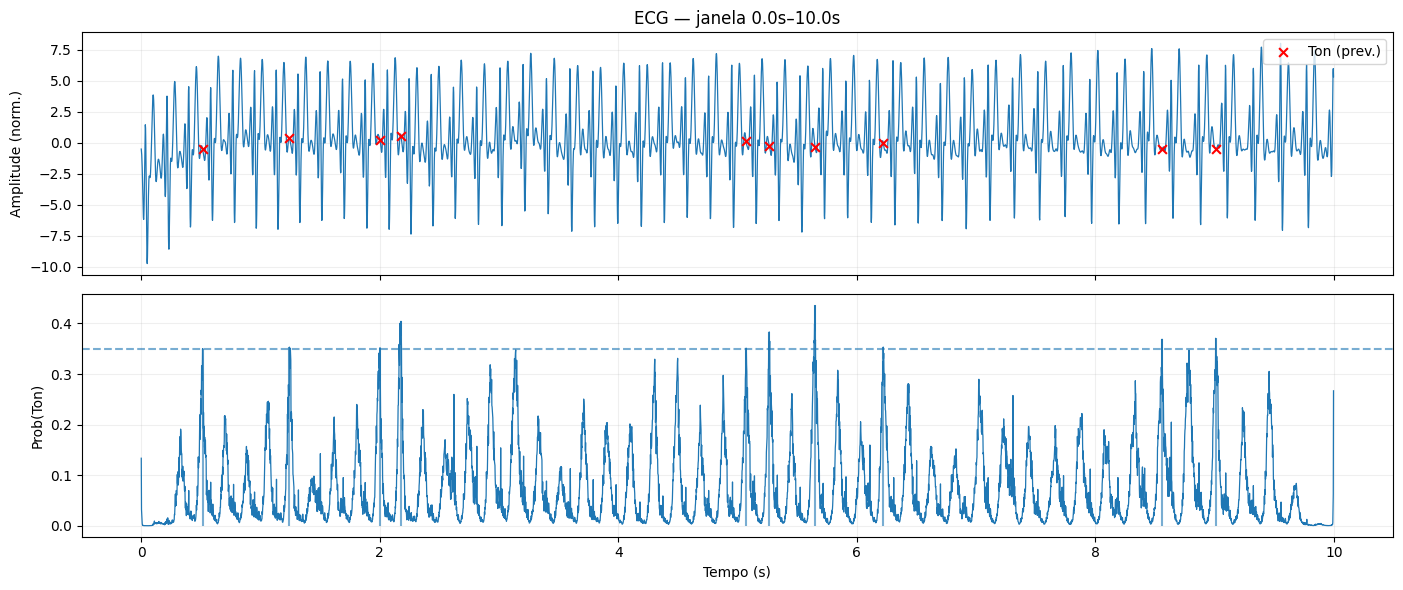

[janela] picos=10  thr_usado=0.349  pm_max_janela=0.436


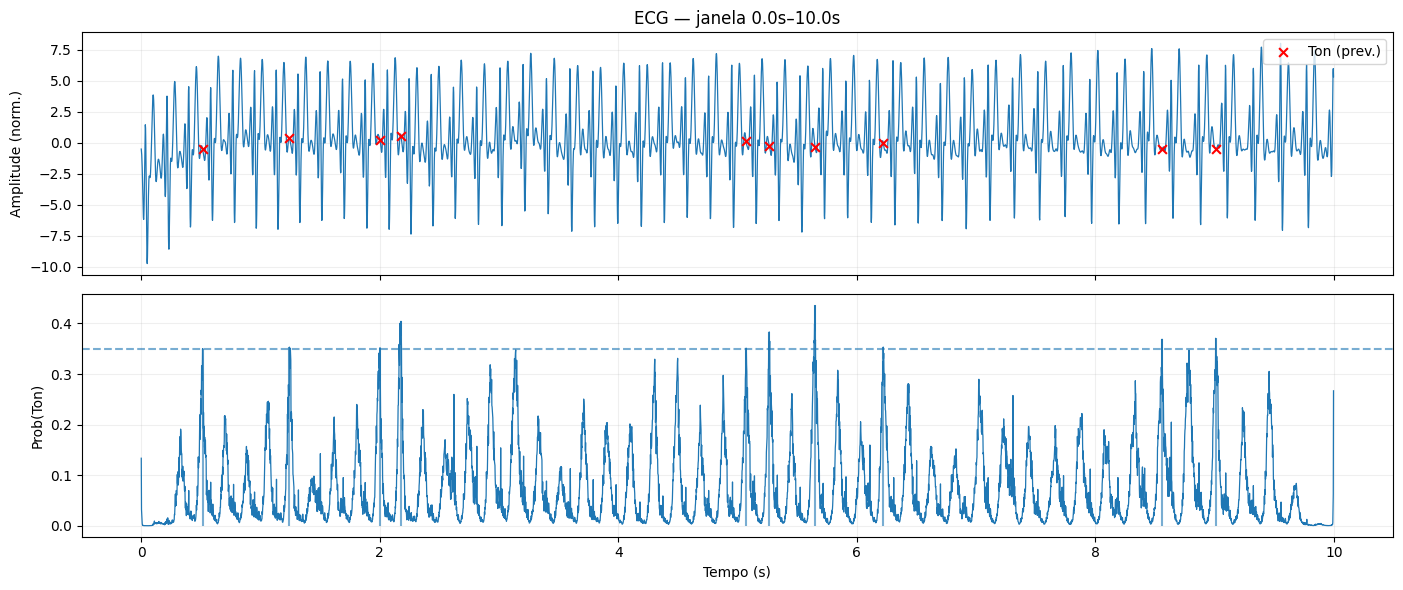

[janela] picos=10  thr_usado=0.349  pm_max_janela=0.436


In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import find_peaks

FS = 500                 # ajuste se não for 500 Hz
MIN_DIST = int(0.12*FS)  # >= 120 ms
WIN_SEC = 10             # tamanho da janela para plot

def pick_peaks_adapt(seg_pm, fs=FS, min_dist=MIN_DIST, thr_fixed=None, perc=80, prom=0.02):
    """
    Detecta picos em um segmento do mapa de probabilidade (0..1).
    - Se thr_fixed for None, usa limiar adaptativo = max(0.15, percentil(perc) dos picos).
    - Usa 'prominence' para evitar ruído.
    Retorna (idx_picos, thr_usado).
    """
    # 1) candidatos por proeminência + distância mínima
    peaks, props = find_peaks(seg_pm, distance=min_dist, prominence=prom)
    if peaks.size == 0:
        return peaks, (thr_fixed if thr_fixed is not None else 0.0)

    # 2) escolhe o limiar
    if thr_fixed is None:
        heights = seg_pm[peaks]
        thr = max(0.15, float(np.percentile(heights, perc)))
    else:
        thr = float(thr_fixed)

    # 3) filtra por altura
    keep = seg_pm[peaks] >= thr
    return peaks[keep], thr

def plot_seg(ecg_arr, pm_arr, start_sec=0.0, dur_sec=10.0, fs=FS, thr_fixed=None):
    """Plota ECG e mapa na janela; usa limiar adaptativo se thr_fixed=None."""
    a = max(0, int(start_sec*fs))
    b = min(len(ecg_arr), a + int(dur_sec*fs))
    if b <= a+5:
        print("[warn] janela vazia/curta"); return

    seg_ecg = ecg_arr[a:b]
    seg_pm  = pm_arr[a:b]

    peaks_win, thr_used = pick_peaks_adapt(seg_pm, fs=fs, min_dist=MIN_DIST,
                                           thr_fixed=thr_fixed, perc=80, prom=0.02)
    t = np.arange(a, b)/fs

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(14,6), sharex=True)

    # ECG
    ax1.plot(t, seg_ecg, lw=0.9)
    if peaks_win.size:
        ax1.scatter((a+peaks_win)/fs, seg_ecg[peaks_win], c='r', marker='x', s=40, label='Ton (prev.)', zorder=3)
        ax1.legend(loc='upper right')
    ax1.set_title(f"ECG — janela {start_sec:.1f}s–{start_sec+dur_sec:.1f}s")
    ax1.set_ylabel("Amplitude (norm.)"); ax1.grid(alpha=0.2)

    # Mapa
    ax2.plot(t, seg_pm, lw=0.9)
    ax2.axhline(thr_used, ls='--', alpha=0.6)
    if peaks_win.size:
        # marcar picos (sem use_line_collection)
        for pk in (a + peaks_win):
            ax2.vlines(pk/fs, 0, pm_arr[pk], alpha=0.6)
    ax2.set_ylabel("Prob(Ton)"); ax2.set_xlabel("Tempo (s)"); ax2.grid(alpha=0.2)
    plt.tight_layout(); plt.show()
    print(f"[janela] picos={len(peaks_win)}  thr_usado={thr_used:.3f}  pm_max_janela={seg_pm.max():.3f}")

# ========= COMO USAR =========
# 1) Primeira janela:
plot_seg(ecg, pred_map, start_sec=0, dur_sec=10, fs=FS, thr_fixed=None)  # adaptativo

# 2) Procurar automaticamente uma janela com picos e plotar:
win = int(WIN_SEC*FS)
peaks_all, _ = find_peaks(pred_map, distance=MIN_DIST, prominence=0.02)
if peaks_all.size:
    p = int(peaks_all[0])
    start_auto = max(0, (p - win//2)/FS)
    plot_seg(ecg, pred_map, start_sec=start_auto, dur_sec=WIN_SEC, fs=FS, thr_fixed=None)
else:
    print("[auto] nenhum pico com proeminência suficiente; tente reduzir 'prom' para 0.01 lá em cima.")


[info] batimentos=187, tons_marcados=187


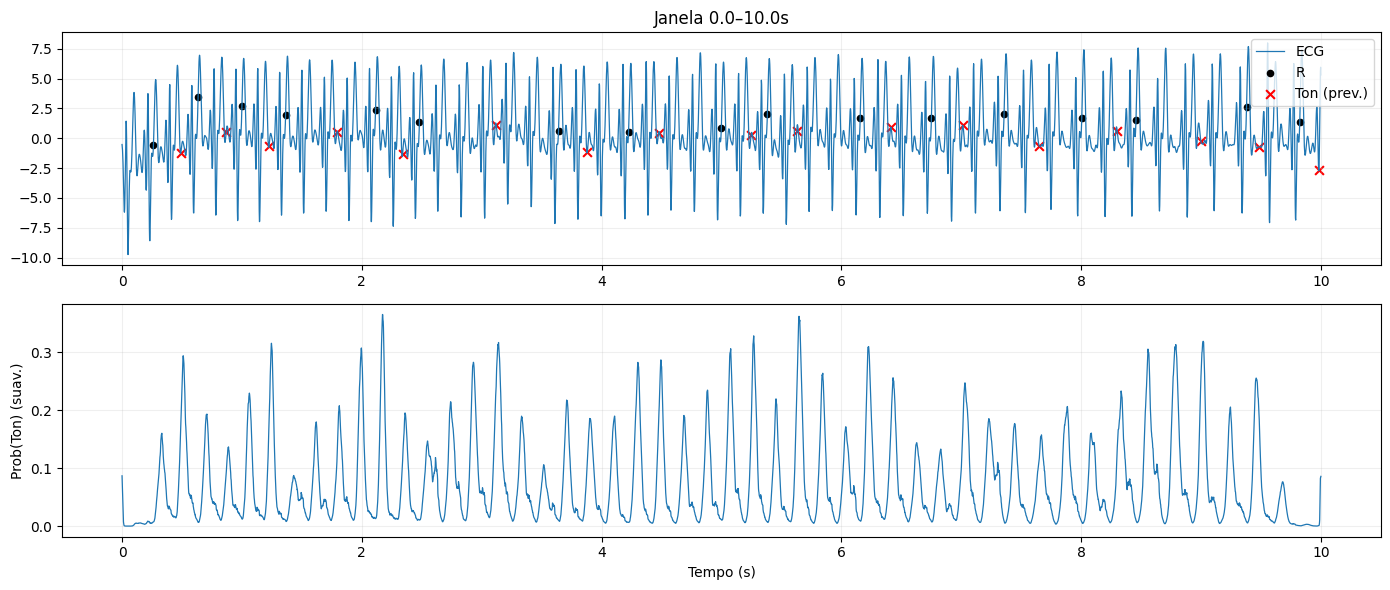

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

FS = 500   # taxa
# ---------- 1) Detector simples de R (gating) ----------
def bandpass_ecg(x, fs=FS, low=8.0, high=20.0, order=2):
    nyq = 0.5*fs
    b,a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b,a,x)

def detect_r_simple(ecg_raw, fs=FS):
    # Pan‑Tompkins "lite": BP 8–20 Hz + quadrado + média móvel + picos
    y = bandpass_ecg(ecg_raw, fs)
    y = y**2
    win = int(0.12*fs)  # ~120 ms
    ma = np.convolve(y, np.ones(win)/win, mode="same")
    # distância mínima entre R ~ 250 ms
    dist = int(0.25*fs)
    # limiar adaptativo
    thr = np.percentile(ma, 85)
    peaks, _ = find_peaks(ma, height=thr, distance=dist)
    return peaks

# ---------- 2) Suavizar o mapa de probabilidade ----------
def smooth(x, k):
    if k <= 1: return x
    k = int(k)
    pad = k//2
    xx = np.pad(x, (pad,pad), mode="edge")
    ker = np.ones(k, dtype=float)/k
    out = np.convolve(xx, ker, mode="valid")
    return out

# ---------- 3) Ton por batimento usando janela fisiológica ----------
def pick_ton_per_beat(pm, R, fs=FS, w_pre_ms=120, rr_frac_max=0.7,
                      min_prom=0.01, perc=70, shift_left_ms=20):
    """Retorna 1 índice Ton por batimento (argmáx do mapa na janela).
       shift_left_ms: aplica um deslocamento à esquerda (Ton ~ antes do T-peak)."""
    if len(R) < 2:  # fallback: picos globais
        peaks, _ = find_peaks(pm, distance=int(0.12*fs), prominence=min_prom)
        return peaks
    tons = []
    for i in range(len(R)-1):
        a = R[i] + int(round(w_pre_ms/1000*fs))
        b = R[i] + int(round(rr_frac_max*(R[i+1]-R[i])))
        a = max(0,a); b = min(len(pm)-1, b)
        if b <= a+2:
            continue
        seg = pm[a:b+1]
        # limiar adaptativo por batimento
        cand, prop = find_peaks(seg, distance=int(0.10*fs), prominence=min_prom)
        if cand.size:
            thr = max(0.10, float(np.percentile(seg[cand], perc)))
            cand = cand[seg[cand] >= thr]
        # se sobrar, escolha o maior; se não, pegue simplesmente o argmáx
        if cand.size:
            k = cand[np.argmax(seg[cand])]
        else:
            k = int(np.argmax(seg))
        idx = a + k
        # deslocar um pouco para a esquerda para aproximar do T‑onset
        idx = max(0, idx - int(round(shift_left_ms/1000*fs)))
        tons.append(idx)
    return np.array(tons, dtype=int)

# ========== EXECUTAR ==========
# 0) garanta que ecg e pred_map existam
assert 'ecg' in globals() and 'pred_map' in globals()

# 1) R-peaks para gating
R = detect_r_simple(ecg, FS)

# 2) suavizar o mapa (20 ms ~ 10 amostras a 500 Hz)
pm_s = smooth(pred_map, k=int(0.02*FS))

# 3) obter 1 Ton por batimento (mais agressivo no recall)
tons = pick_ton_per_beat(pm_s, R, fs=FS, w_pre_ms=120, rr_frac_max=0.70,
                         min_prom=0.01, perc=70, shift_left_ms=20)

print(f"[info] batimentos={len(R)-1}, tons_marcados={len(tons)}")

# 4) plotar uma janela de 10 s a partir do início (ajuste start_sec)
def plot_window(start_sec=0, dur_sec=10):
    a = int(start_sec*FS); b = min(len(ecg), a+int(dur_sec*FS))
    t = np.arange(a,b)/FS
    mask_t = (tons>=a) & (tons<b)
    mask_r = (R>=a) & (R<b)
    plt.figure(figsize=(14,6))
    ax1 = plt.subplot(2,1,1)
    ax1.plot(t, ecg[a:b], lw=0.9, label="ECG")
    ax1.scatter(R[mask_r]/FS, ecg[R[mask_r]], s=20, c='k', marker='o', label='R')
    if mask_t.any():
        ax1.scatter(tons[mask_t]/FS, ecg[tons[mask_t]], s=40, c='r', marker='x', label='Ton (prev.)')
    ax1.legend(loc='upper right'); ax1.grid(alpha=0.2)
    ax1.set_title(f"Janela {start_sec:.1f}–{start_sec+dur_sec:.1f}s")

    ax2 = plt.subplot(2,1,2, sharex=ax1)
    ax2.plot(t, pm_s[a:b], lw=0.9)
    ax2.set_ylabel("Prob(Ton) (suav.)"); ax2.set_xlabel("Tempo (s)")
    ax2.grid(alpha=0.2)
    plt.tight_layout(); plt.show()

# exemplos
plot_window(0, 10)
# plot_window(30, 10); plot_window(60, 10)


In [ ]:
import wfdb

# caminho base sem extensão (.dat/.hea/.v3 precisam estar juntos em ROOT)
base = "/content/drive/My Drive/onda_T/data/91"

# abre anotação da lead V3
ann = wfdb.rdann(base, "v3")

print("Total de marcações:", len(ann.sample))
for i in range(min(20, len(ann.sample))):
    print(f"{i:02d}  sample={ann.sample[i]}  symbol={ann.symbol[i]!r}  aux={ann.aux_note[i]!r}")


Total de marcações: 93
00  sample=520  symbol='('  aux=''
01  sample=538  symbol='N'  aux=''
02  sample=566  symbol=')'  aux=''
03  sample=587  symbol='('  aux=''
04  sample=660  symbol='t'  aux=''
05  sample=696  symbol=')'  aux=''
06  sample=814  symbol='('  aux=''
07  sample=833  symbol='p'  aux=''
08  sample=846  symbol=')'  aux=''
09  sample=886  symbol='('  aux=''
10  sample=905  symbol='N'  aux=''
11  sample=939  symbol=')'  aux=''
12  sample=958  symbol='('  aux=''
13  sample=1027  symbol='t'  aux=''
14  sample=1072  symbol=')'  aux=''
15  sample=1185  symbol='('  aux=''
16  sample=1205  symbol='p'  aux=''
17  sample=1217  symbol=')'  aux=''
18  sample=1259  symbol='('  aux=''
19  sample=1276  symbol='N'  aux=''
